# SARIMA vs. SARIMAX con datos reales
## Incidencia de dengue y clima en Montería (Córdoba, Colombia), 2007–2023

**Pregunta de la clase:** ¿mejora el pronóstico del dengue si al modelo le damos información del clima?

**Caso de referencia.** Medina, Cogollo y González-Parra (2024) ajustaron un SARIMAX para la incidencia de dengue en Córdoba con precipitación y humedad relativa como variables exógenas (*Mathematical Biosciences and Engineering*, 21(12), 7760–7782, DOI 10.3934/mbe.2024341). Su mejor modelo fue SARIMAX(4,1,3)(1,0,1)[13].

**Datos.** Marceló-Díaz y otros (2026), Universidad del Rosario, Zenodo, DOI 10.5281/zenodo.21538313, licencia CC BY 4.0. Casos de SIVIGILA, población del DANE, lluvia de CHIRPS y humedad y temperatura de MSWX.

**Qué cambia frente al artículo.** Aquí usamos el municipio de Montería en lugar del departamento, meses en lugar de periodos epidemiológicos (m = 12 en lugar de 13) y clima de productos grillados en lugar de estaciones del IDEAM. Es una adaptación, no una réplica exacta.

### Cómo está organizado

Las secciones 0 a 9 son el recorrido básico: mirar, transformar, elegir rezago, partir, ajustar SARIMA y SARIMAX, diagnosticar y pronosticar. Es la comparación que suele aparecer en los artículos aplicados.

Las secciones 10 a 18 son el **control de calidad** que esa comparación todavía no ha pasado, y es donde está la parte difícil del oficio:

| Sección | Pregunta que responde |
|---|---|
| 10 | ¿Le ganamos a un pronóstico trivial? (MASE, benchmarks) |
| 11 | Al volver de log a casos, ¿`exp` da la media o la mediana? |
| 12 | ¿Los intervalos de predicción sirven para decidir algo? |
| 13 | ¿Y si no conocemos el clima futuro? (pronóstico *ex ante*) |
| 14 | ¿El resultado aguanta más de una partición? (origen rodante) |
| 15 | ¿La diferencia es estadísticamente significativa? (Diebold-Mariano) |
| 16 | ¿El clima informa, o solo imita la estacionalidad? (Fourier) |
| 17 | ¿Hubo una ruptura en 2020? |
| 18 | ¿Qué orden elegir sin mirar la prueba? (AICc) |

El orden importa: **la conclusión de la sección 9 no sobrevive intacta a las secciones 14 a 16.** Vale la pena leerlas en orden y no adelantarse al final.

**Requisitos.** Los paquetes pandas, numpy, scipy, matplotlib y statsmodels. Los datos se leen de `03_datos/compartidos/datos_sarimax.xlsx` del repositorio: si el archivo no está en disco, la celda de carga lo descarga de GitHub, así que el notebook también corre en Colab.

## 0. Preparación

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats as st
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

# Paleta categórica en orden fijo, verificada para daltonismo (deuteranopía y tritanopía).
# Se asigna por modelo, nunca por posición en el ranking, y siempre acompañada de
# leyenda y estilo de línea distinto: el color nunca es el único indicador.
PAL = ["#0072B2", "#D55E00", "#009E73", "#9467BD"]
OBS = "#111111"   # reservado para la serie observada

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.30
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PAL)

for p in (np, pd, sm):
    print(f"{p.__name__:12s} {p.__version__}")

numpy        2.4.4
pandas       2.3.3
statsmodels.api 0.14.6


## 1. Los datos

| Columna | Contenido |
|---|---|
| `Y` | Tasa de incidencia de dengue, casos por 100.000 habitantes |
| `X1` | Precipitación total del mes (mm) |
| `X2` | Humedad relativa media (%) |
| `X3` | Temperatura media del aire (°C) |
| `Casos`, `Poblacion` | Casos notificados y población del municipio |

In [2]:
RUTA = "../03_datos/compartidos/datos_sarimax.xlsx"
URL = "https://github.com/Wilsonsr/Series-de-Tiempo/raw/main/03_datos/compartidos/datos_sarimax.xlsx"

fuente = RUTA if os.path.exists(RUTA) else URL
df = (pd.read_excel(fuente, sheet_name="datos", parse_dates=["Fecha"])
        .set_index("Fecha").asfreq("MS"))

print("Fuente:", "archivo local" if fuente is RUTA else "GitHub")
print("Observaciones:", len(df), "| desde", df.index.min().date(), "hasta", df.index.max().date())
print("Valores faltantes:", int(df.isna().sum().sum()))
df.head()

Fuente: archivo local
Observaciones: 204 | desde 2007-01-01 hasta 2023-12-01
Valores faltantes: 0


,Y,X1,X2,X3,Casos,Poblacion
Fecha,,,,,,
2007-01-01,4.627637,7.902693,80.495207,28.966859,20,432186
2007-02-01,1.388291,8.549954,71.459016,29.535048,6,432186
2007-03-01,5.090401,64.675817,76.062253,29.359146,22,432186
2007-04-01,2.313819,204.668149,86.006274,28.491712,10,432186
2007-05-01,4.396255,202.073510,87.988034,28.213049,19,432186


In [3]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Y,204.0,13.98,14.49,0.22,3.98,8.49,19.35,76.98
X1,204.0,124.12,75.49,4.88,51.58,142.20,186.38,311.96
X2,204.0,82.77,4.86,69.26,80.50,84.89,86.09,88.29
X3,204.0,29.00,0.68,27.55,28.55,28.92,29.50,31.07
Casos,204.0,68.23,72.48,1.00,18.00,40.00,93.25,384.00
Poblacion,204.0,475570.94,28900.20,432186.00,452158.00,473413.00,498858.00,523150.00


## 2. Mirar antes de modelar

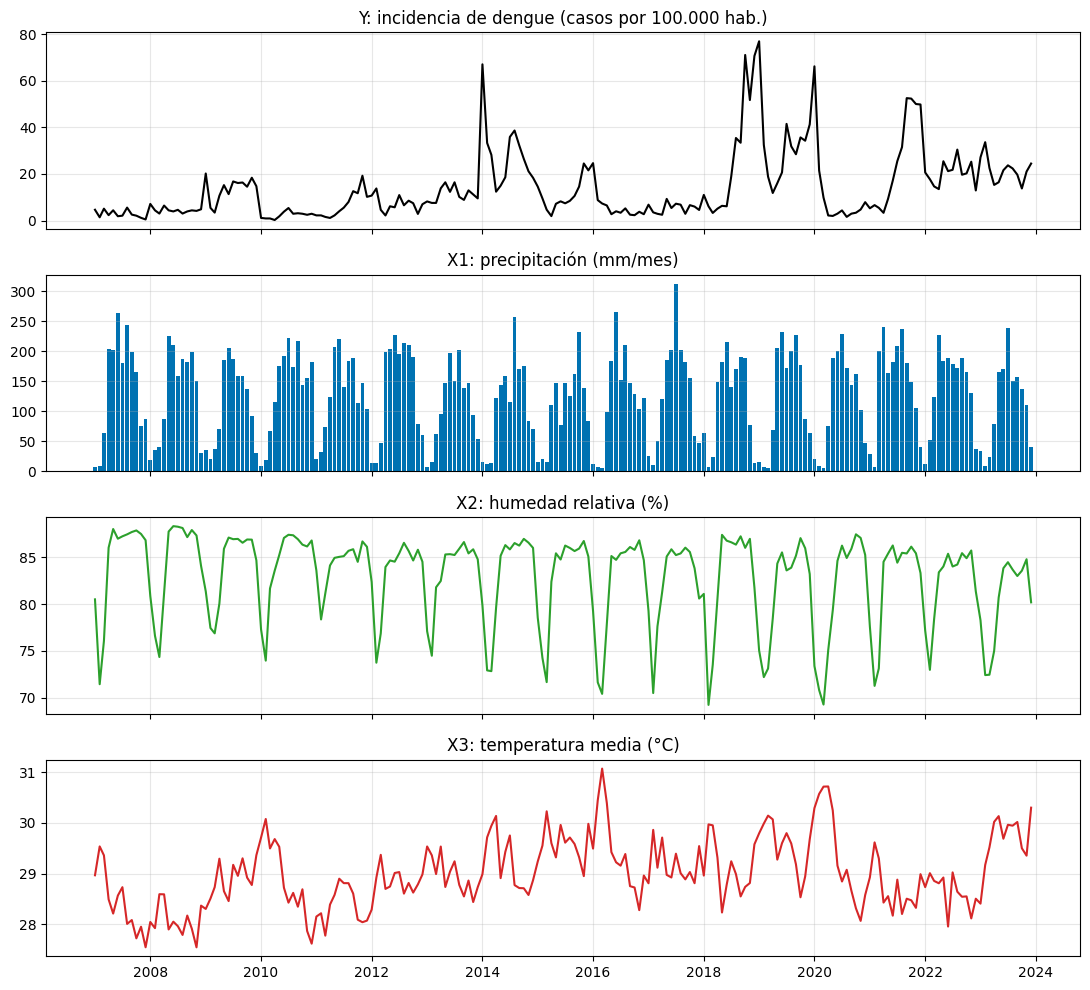

In [4]:
fig, ax = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
ax[0].plot(df["Y"], color="black");      ax[0].set_title("Y: incidencia de dengue (casos por 100.000 hab.)")
ax[1].bar(df.index, df["X1"], width=25); ax[1].set_title("X1: precipitación (mm/mes)")
ax[2].plot(df["X2"], color="tab:green"); ax[2].set_title("X2: humedad relativa (%)")
ax[3].plot(df["X3"], color="tab:red");   ax[3].set_title("X3: temperatura media (°C)")
plt.tight_layout(); plt.show()

**Para discutir.** El dengue no tiene una estacionalidad limpia: hay años epidémicos (2014, 2018–2019, 2021) y años casi planos. El clima sí repite su ciclo cada año. ¿Qué parte del dengue puede explicar entonces el clima?

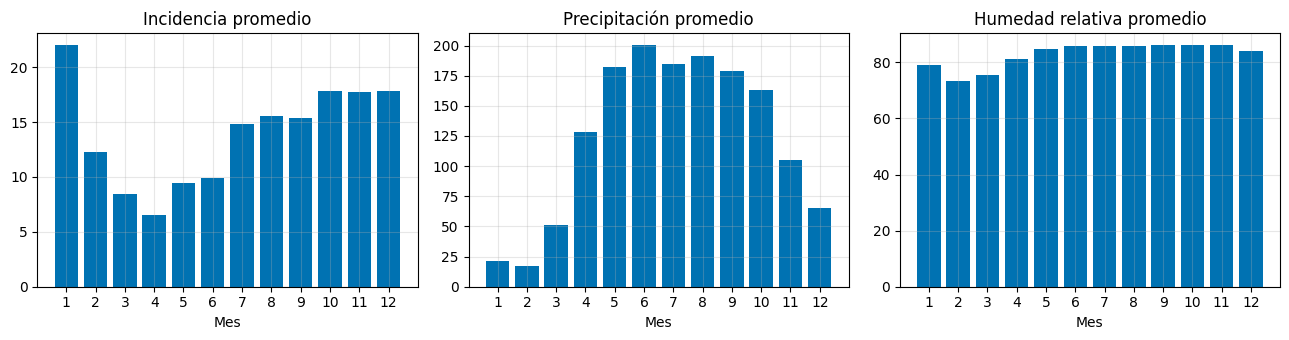

In [5]:
mensual = df.groupby(df.index.month)[["Y", "X1", "X2"]].mean()
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
for a, col, t in zip(ax, ["Y", "X1", "X2"], ["Incidencia promedio", "Precipitación promedio", "Humedad relativa promedio"]):
    a.bar(mensual.index, mensual[col]); a.set_title(t); a.set_xlabel("Mes"); a.set_xticks(range(1, 13))
plt.tight_layout(); plt.show()

**Lectura.** La lluvia y la humedad suben desde abril o mayo. La incidencia promedio es más alta en la segunda mitad del año. Ese desfase es la primera pista de que el clima actúa con retraso.

## 3. Transformación y estacionariedad

La serie tiene picos muy altos y varianza que crece con el nivel. El logaritmo la estabiliza. Montería no tiene meses con cero casos, así que no hay problema con log(0).

En lugar de *afirmar* que el log es la transformación correcta, la estimamos: Box-Cox tiene un parámetro λ, y el caso λ = 0 **es** el logaritmo.

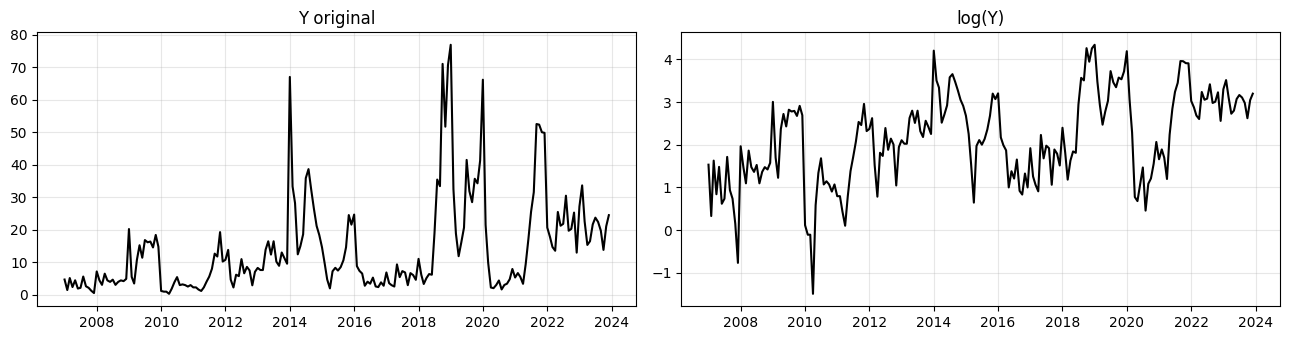

In [6]:
y = np.log(df["Y"])
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
ax[0].plot(df["Y"], color="black"); ax[0].set_title("Y original")
ax[1].plot(y, color="black");       ax[1].set_title("log(Y)")
plt.tight_layout(); plt.show()

In [7]:
# λ se estima SOLO con el entrenamiento: es una decisión de modelado, no un resumen de los datos.
INI, FIN_TRAIN, INI_TEST = "2007-07", "2021-12", "2022-01"

lam = st.boxcox_normmax(df["Y"][INI:FIN_TRAIN].values, method="mle")
print(f"λ de Box-Cox estimado por máxima verosimilitud = {lam:.3f}")
print("λ = 0 es exactamente log(Y);  λ = 1 sería no transformar.")

λ de Box-Cox estimado por máxima verosimilitud = 0.026
λ = 0 es exactamente log(Y);  λ = 1 sería no transformar.


**Lectura.** λ ≈ 0,03, indistinguible de 0. El logaritmo no es una costumbre heredada: es la transformación que los datos piden. Y tiene un beneficio adicional, que los coeficientes queden en una escala interpretable como cambios relativos.

In [8]:
# Una sola prueba no basta: ADF y KPSS tienen hipótesis nulas OPUESTAS.
#   ADF   H0: hay raíz unitaria (no estacionaria)  ->  queremos p pequeño
#   KPSS  H0: la serie es estacionaria             ->  queremos p grande
# Y el veredicto depende de qué términos deterministas se permitan:
#   "c" = solo constante      "ct" = constante y tendencia lineal
y = np.log(df["Y"])

filas = []
for nombre, serie in [("log(Y)", y[INI:FIN_TRAIN]),
                      ("Δ log(Y)", y[INI:FIN_TRAIN].diff().dropna())]:
    for reg in ("c", "ct"):
        p_adf = adfuller(serie, regression=reg, autolag="AIC")[1]
        p_kpss = kpss(serie, regression=reg, nlags="auto")[1]
        filas.append({"Serie": nombre, "Términos": reg,
                      "ADF p": round(p_adf, 4), "KPSS p": round(p_kpss, 4),
                      "Veredicto": "estacionaria" if (p_adf < 0.05 and p_kpss > 0.05) else "EN DISPUTA"})
pd.DataFrame(filas)

,Serie,Términos,ADF p,KPSS p,Veredicto
0,log(Y),c,0.0008,0.0358,EN DISPUTA
1,log(Y),ct,0.0013,0.1000,estacionaria
2,Δ log(Y),c,0.0000,0.1000,estacionaria
3,Δ log(Y),ct,0.0000,0.1000,estacionaria


**Lectura, y una corrección al atajo habitual.** Con solo constante las dos pruebas **se contradicen**: ADF rechaza la raíz unitaria (p = 0,0008) y KPSS también rechaza la estacionariedad (p = 0,036). Eso no es un empate, es un síntoma: hay un componente determinista que ninguno de los dos modelos nulos está recogiendo.

Al permitir tendencia (`ct`) las dos coinciden: log(Y) es estacionaria **alrededor de una tendencia**. Y la tendencia existe, como verificamos enseguida. Entonces **d = 0 es defendible, pero solo si se reconoce la tendencia**. Este notebook la deja fuera del modelo: es una simplificación consciente, no un hallazgo.

Dos prácticas frecuentes que aquí corregimos:

- **Probar estacionariedad sobre la serie completa.** Cuánto diferenciar es parte del modelo, así que se decide con el entrenamiento. Mirar 2022–2023 para fijar `d` ya contamina la evaluación.
- **Reportar una sola prueba con sus opciones por defecto.** `adfuller(serie)` usa `regression="c"`, que es justo donde está la ambigüedad.

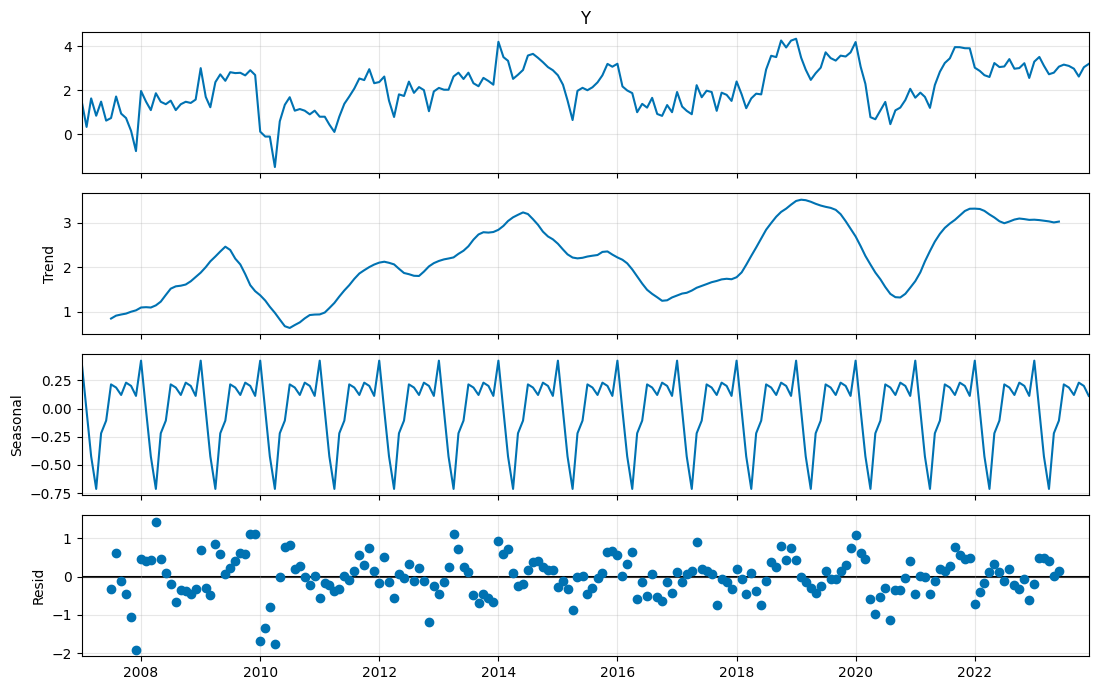

In [9]:
desc = seasonal_decompose(y, model="additive", period=12)
fig = desc.plot(); fig.set_size_inches(11, 7); plt.tight_layout(); plt.show()

In [10]:
# ¿Hay tendencia? ¿Solo en el dengue, o también en el clima?
# Errores estándar HAC (Newey-West): con series autocorrelacionadas los de OLS mienten.
t = np.arange(len(y[INI:FIN_TRAIN]))
for nombre, s in [("log(Y) dengue", y), ("X1 precipitación", df["X1"]),
                  ("X2 humedad", df["X2"]), ("X3 temperatura", df["X3"])]:
    r = sm.OLS(s[INI:FIN_TRAIN].values, sm.add_constant(t)).fit(
        cov_type="HAC", cov_kwds={"maxlags": 12})
    print(f"{nombre:18s} cambio por década = {r.params[1] * 120:+8.3f}    p(HAC) = {r.pvalues[1]:.4f}")

log(Y) dengue      cambio por década =   +0.966    p(HAC) = 0.0144
X1 precipitación   cambio por década =   +0.076    p(HAC) = 0.9938
X2 humedad         cambio por década =   -2.149    p(HAC) = 0.0014
X3 temperatura     cambio por década =   +0.665    p(HAC) = 0.0200


**Lectura, y aquí hay una sorpresa útil.** La incidencia **sube** (+0,97 en log por década) y la humedad relativa **baja** (−2,15 puntos porcentuales por década). Las dos tendencias van en direcciones opuestas.

Eso descarta de entrada la sospecha más obvia sobre lo que viene en la sección 7. Cuando dos series suben juntas, un coeficiente positivo puede ser puro artefacto de tendencia compartida. Aquí no puede serlo, porque las tendencias se oponen. De hecho, al agregar una tendencia al modelo el coeficiente de la humedad **se duplica** (0,028 → 0,059): la tendencia estaba *escondiendo* la relación, no fabricándola.

Moraleja general, aplicable a cualquier regresión con series de tiempo: antes de celebrar o descartar un coeficiente, mirar si las dos series tienen tendencia y hacia dónde.

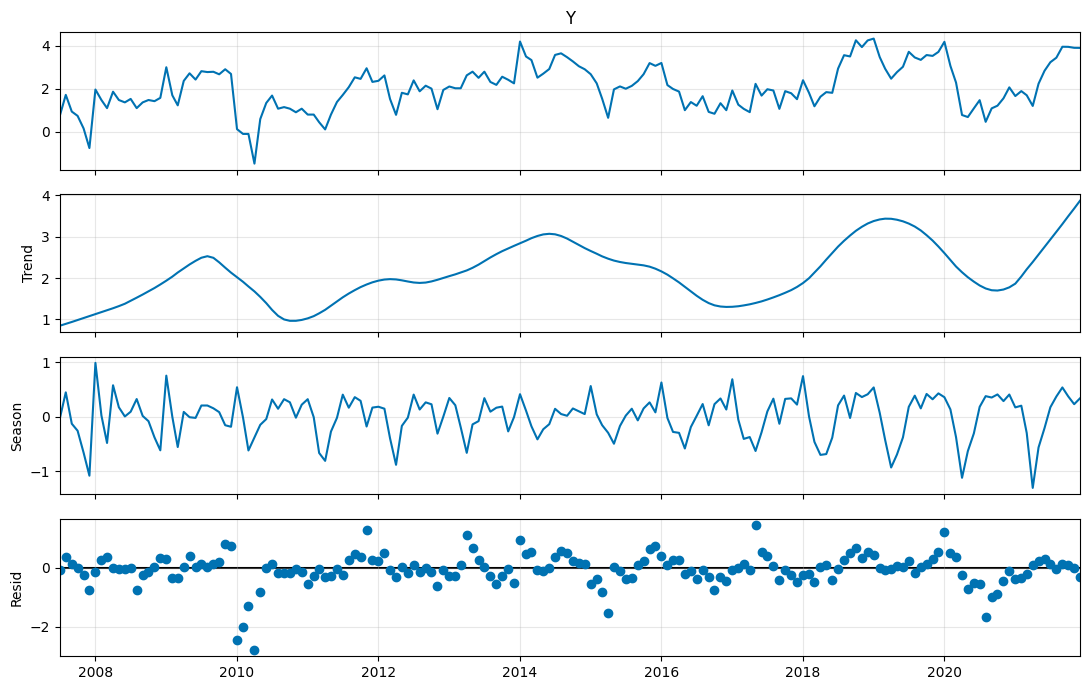

Fuerza de estacionalidad  Fs = 0.349
Fuerza de tendencia       Ft = 0.679


In [11]:
# STL robusta: a diferencia de seasonal_decompose, permite que la estacionalidad cambie con los
# años y usa pesos que impiden que 2014 o 2019 dominen la curva estacional.
stl = STL(y[INI:FIN_TRAIN], period=12, robust=True).fit()
fig = stl.plot(); fig.set_size_inches(11, 7); plt.tight_layout(); plt.show()

# Fuerza de estacionalidad y de tendencia (Hyndman & Athanasopoulos): 0 = nada, 1 = todo.
var = lambda s: np.var(s, ddof=1)
Fs = max(0.0, 1 - var(stl.resid) / var(stl.seasonal + stl.resid))
Ft = max(0.0, 1 - var(stl.resid) / var(stl.trend + stl.resid))
print(f"Fuerza de estacionalidad  Fs = {Fs:.3f}")
print(f"Fuerza de tendencia       Ft = {Ft:.3f}")

**Lectura.** Fs = 0,35 le pone número a lo que ya decía el gráfico: la estacionalidad del dengue en Montería es **débil**. Como referencia, las series estacionales de manual (temperatura, consumo de gas) pasan de 0,90. Con Fs tan bajo:

- **D = 0** queda bien justificado. No hay un ciclo anual lo bastante estable como para diferenciarlo.
- El modelo tiene poco que ganar de su parte estacional, y por eso un pronóstico estacional ingenuo va a funcionar mal (sección 10).
- Ft = 0,68 confirma que el movimiento lento domina sobre el ciclo anual.

Reportar Fs y Ft cuesta tres líneas y evita discusiones de sobremesa sobre si la serie "se ve estacional".

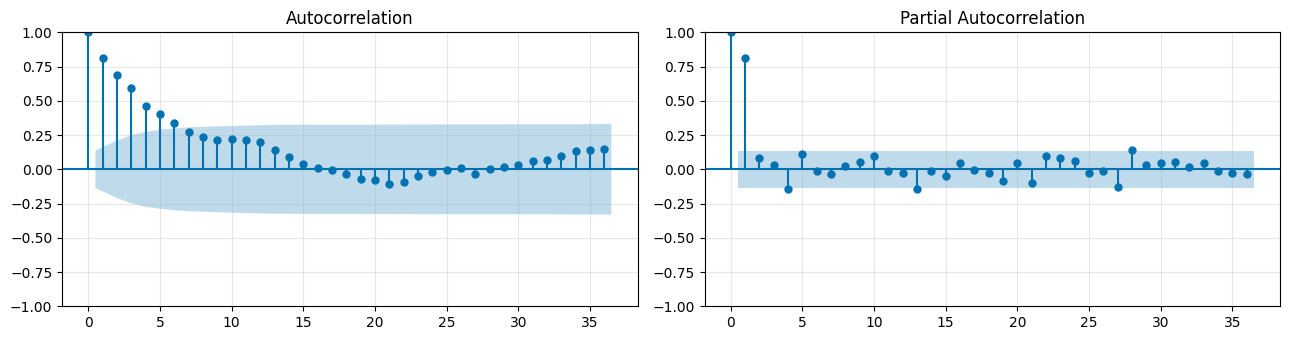

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
plot_acf(y, lags=36, ax=ax[0]); plot_pacf(y, lags=36, ax=ax[1], method="ywm")
plt.tight_layout(); plt.show()

**Lectura.** La ACF decae lentamente y la PACF se corta después del primer rezago: comportamiento autorregresivo de orden bajo. Eso sugiere empezar con p = 1.

## 4. ¿Con cuánto retraso actúa el clima?

Entre la lluvia y un caso notificado pasan el ciclo del mosquito, la incubación en el vector y en la persona, y la notificación. Buscamos el rezago con la correlación entre log(Y) y cada X desplazada k meses.

**Regla de oro:** esta elección se hace solo con los datos de entrenamiento. Mirar el periodo de prueba para elegir el rezago sería hacer trampa.

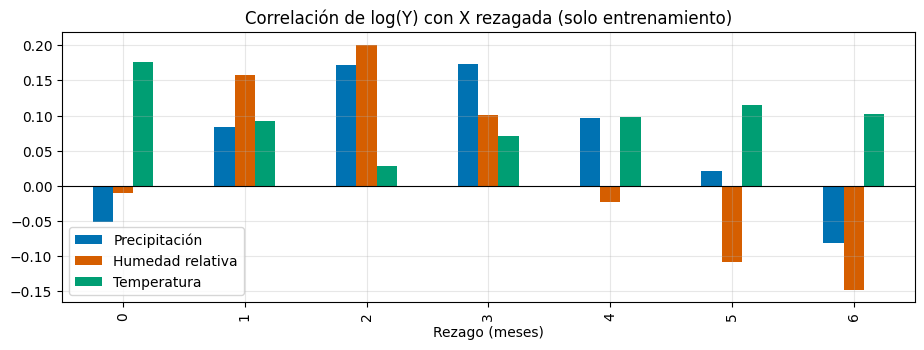

,Precipitación,Humedad relativa,Temperatura
Rezago (meses),,,
0,-0.05,-0.01,0.18
1,0.08,0.16,0.09
2,0.17,0.20,0.03
3,0.17,0.10,0.07
4,0.10,-0.02,0.10
5,0.02,-0.11,0.11
6,-0.08,-0.15,0.10


In [13]:
INI, FIN_TRAIN, INI_TEST = "2007-07", "2021-12", "2022-01"

y_tr_tmp = y[INI:FIN_TRAIN]
ccf = pd.DataFrame({
    nombre: [y_tr_tmp.corr(df[col].shift(k)[INI:FIN_TRAIN]) for k in range(7)]
    for col, nombre in [("X1", "Precipitación"), ("X2", "Humedad relativa"), ("X3", "Temperatura")]
})
ccf.index.name = "Rezago (meses)"
ax = ccf.plot(kind="bar", figsize=(11, 3.5), title="Correlación de log(Y) con X rezagada (solo entrenamiento)")
ax.axhline(0, color="black", lw=0.8); plt.show()
ccf.round(2)

**Lectura preliminar.** Precipitación y humedad alcanzan su mayor correlación a 2 meses. Las correlaciones son bajas (alrededor de 0,2): el clima ayuda, pero no es el motor principal. El artículo usa esas dos variables, así que seguimos con **rezago 2**.

Ventaja práctica del rezago: para pronosticar el mes siguiente ya conocemos el clima de hace dos meses. No hay que pronosticar las exógenas.

**Pero este gráfico no se puede leer así.** Es el error más frecuente al buscar rezagos, y lo corregimos en 4.1 antes de seguir.

### 4.1 Por qué la correlación cruzada cruda engaña

Dos series muy autocorrelacionadas se correlacionan entre sí **aunque no tengan ninguna relación**. Es el problema clásico de la regresión espuria, y en una CCF aparece por dos vías:

1. **Sesgo.** La correlación muestral entre dos procesos autocorrelacionados no converge a 0 aunque sean independientes.
2. **Bandas mal calibradas.** La banda ±2/√n supone observaciones independientes. Con autocorrelación el error estándar verdadero es bastante mayor, así que la banda que uno dibuja es **demasiado estrecha** y marca como significativo lo que no lo es.

Y hay un tercer problema, específico de este caso: log(Y) y la humedad **comparten el ciclo anual**. Cualquier par de series con el mismo ciclo anual se correlaciona a rezagos de unos pocos meses por pura geometría del seno, sin que una cause ni anticipe a la otra.

La solución de Box y Jenkins es el **preblanqueo** (*prewhitening*):

1. Ajustar un ARMA a la serie **X** hasta que sus residuos sean ruido blanco. Ese es el filtro.
2. Aplicar **el mismo filtro, con los mismos parámetros**, a la serie **Y**.
3. Calcular la CCF entre las dos series filtradas.

Así se elimina la estructura que X comparte consigo misma, y lo que quede es la relación entre X e Y que no es un reflejo de sus propias inercias.

In [14]:
# Paso 1: elegir el filtro que de verdad deja blanca a cada X, no uno cualquiera.
# Se compara por AIC y se verifica con Ljung-Box: si la X filtrada todavía tiene
# autocorrelación, el preblanqueo no sirvió y su CCF no es confiable.
ytr = y[INI:FIN_TRAIN]
CANDIDATOS = [((1, 0, 0), (1, 0, 0, 12)), ((2, 0, 0), (1, 0, 0, 12)),
              ((2, 0, 0), (2, 0, 0, 12)), ((1, 0, 1), (1, 0, 1, 12))]

filtros = {}
for col in ["X1", "X2", "X3"]:
    xs = df[col][INI:FIN_TRAIN]
    mejor = None
    for orden, orden_est in CANDIDATOS:
        m = SARIMAX(xs, order=orden, seasonal_order=orden_est, trend="c").fit(disp=False, maxiter=800)
        gl = sum(orden) + orden_est[0] + orden_est[2]
        p_lb = acorr_ljungbox(m.resid[13:], lags=[24], model_df=gl)["lb_pvalue"].iloc[0]
        if mejor is None or m.aic < mejor[0]:
            mejor = (m.aic, orden, orden_est, m, p_lb)
    filtros[col] = mejor
    aviso = "" if mejor[4] > 0.05 else "   <-- no quedó del todo blanca"
    print(f"{col}: filtro {mejor[1]}{mejor[2]}  AIC = {mejor[0]:7.1f}  "
          f"Ljung-Box de la X filtrada p = {mejor[4]:.3f}{aviso}")

X1: filtro (1, 0, 1)(1, 0, 1, 12)  AIC =  1787.9  Ljung-Box de la X filtrada p = 0.563


X2: filtro (2, 0, 0)(2, 0, 0, 12)  AIC =   761.2  Ljung-Box de la X filtrada p = 0.027   <-- no quedó del todo blanca


X3: filtro (1, 0, 1)(1, 0, 1, 12)  AIC =   186.9  Ljung-Box de la X filtrada p = 0.210


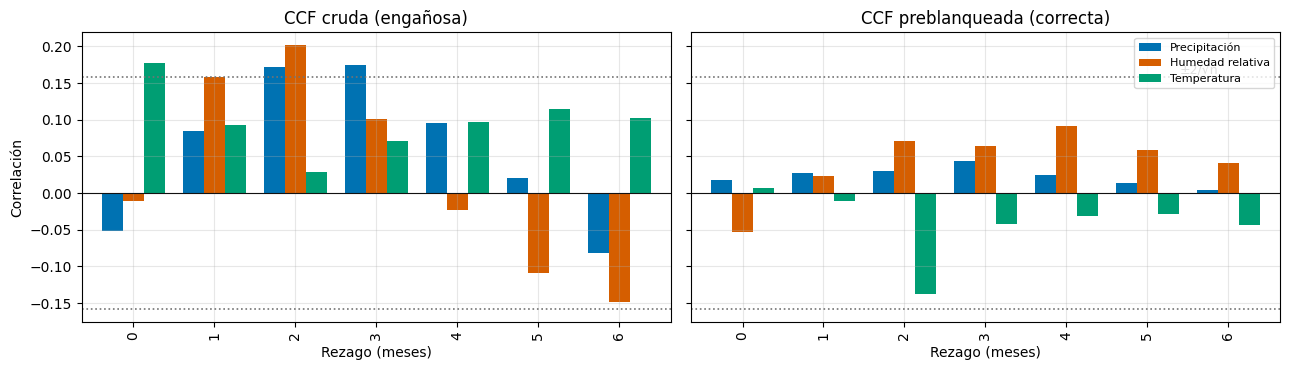

Banda ±2/√n = ±0.158


,Precipitación,Humedad relativa,Temperatura
Rezago (meses),,,
0,0.018,-0.053,0.007
1,0.027,0.023,-0.011
2,0.031,0.071,-0.137
3,0.044,0.063,-0.043
4,0.024,0.092,-0.032
5,0.014,0.058,-0.028
6,0.004,0.041,-0.043


In [15]:
# Pasos 2 y 3: filtrar Y con los parámetros de X, y correlacionar las dos series filtradas.
def ccf_preblanqueada(col, kmax=6):
    _, orden, orden_est, mx, _ = filtros[col]
    alpha = pd.Series(mx.resid, index=df[col][INI:FIN_TRAIN].index).iloc[13:]      # X ya blanca
    molde = SARIMAX(ytr, order=orden, seasonal_order=orden_est, trend="c")         # el MISMO filtro...
    beta = pd.Series(molde.filter(mx.params).resid, index=ytr.index).iloc[13:]     # ...aplicado a Y
    return pd.Series({k: beta.corr(alpha.shift(k)) for k in range(kmax + 1)})

NOMBRES = {"X1": "Precipitación", "X2": "Humedad relativa", "X3": "Temperatura"}
ccf_pb = pd.DataFrame({NOMBRES[c]: ccf_preblanqueada(c) for c in ["X1", "X2", "X3"]})
ccf_pb.index.name = "Rezago (meses)"
banda = 2 / np.sqrt(len(ytr) - 13)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for a, tabla, titulo in [(ax[0], ccf, "CCF cruda (engañosa)"),
                         (ax[1], ccf_pb, "CCF preblanqueada (correcta)")]:
    tabla.plot(kind="bar", ax=a, width=0.78, legend=False)
    a.axhline(0, color=OBS, lw=0.8)
    for signo in (+1, -1):
        a.axhline(signo * banda, color="0.45", ls=":", lw=1.2)
    a.set_title(titulo); a.set_xlabel("Rezago (meses)")
ax[0].set_ylabel("Correlación")
ax[1].legend(loc="upper right", fontsize=8)
ax[1].annotate("±2/√n", xy=(5.4, banda), color="0.35", fontsize=9, va="bottom")
plt.tight_layout(); plt.show()

print(f"Banda ±2/√n = ±{banda:.3f}")
ccf_pb.round(3)

**Lectura, y es incómoda.** Después del preblanqueo **no queda casi nada**. La precipitación no pasa de 0,04 en ningún rezago y la humedad no pasa de 0,09, contra una banda de ±0,158. Las correlaciones de ~0,20 del gráfico crudo eran, en su mayor parte, el ciclo anual que las dos series comparten, no una señal de que el clima anticipe al dengue.

Ni una sola de las 21 correlaciones sale de la banda. La más grande en valor absoluto es la **temperatura a 2 meses, y es negativa** (−0,137 contra una banda de 0,158), es decir, dentro. Con 21 correlaciones calculadas, incluso un par de valores apenas por fuera serían lo esperable por azar; aquí no hay ni eso.

Advertencia honesta sobre nuestro propio cálculo: el filtro de X2 no dejó la serie perfectamente blanca (Ljung-Box p = 0,027), así que su columna es la menos confiable de las tres.

**¿Entonces por qué el SARIMAX de la sección 7 va a funcionar?** Porque son dos preguntas distintas, y conviene separarlas desde ahora:

| Pregunta | Herramienta | Respuesta aquí |
|---|---|---|
| ¿El clima **anticipa** al dengue, más allá de la inercia y del ciclo anual? | CCF preblanqueada | **No** |
| ¿Agregar clima al modelo **mejora el pronóstico**? | Validación fuera de muestra | Sí (secciones 9 y 14) |

No hay contradicción. El preblanqueo elimina a propósito la estacionalidad compartida; el SARIMAX la aprovecha. Una variable exógena puede ser útil **justo porque** trae consigo el ciclo anual, sin aportar ninguna alerta temprana. Esa sospecha queda planteada aquí y la ponemos a prueba en la **sección 16**.

In [16]:
LAG = 2
X = pd.DataFrame({
    "precip_lag2": df["X1"].shift(LAG) / 100,   # en cientos de mm, para que el coeficiente sea legible
    "hr_lag2":     df["X2"].shift(LAG),         # en %
})
X.head(4)

,precip_lag2,hr_lag2
Fecha,,
2007-01-01,NaN,NaN
2007-02-01,NaN,NaN
2007-03-01,0.079027,80.495207
2007-04-01,0.085500,71.459016


## 5. Entrenamiento y prueba

- **Entrenamiento:** julio 2007 a diciembre 2021 (174 meses).
- **Prueba:** enero 2022 a diciembre 2023 (24 meses). El modelo nunca ve estos datos al estimar.

Dos detalles que conviene tener presentes:

- El inicio en **julio de 2007** descarta los primeros meses. Con rezago 2 bastaría arrancar en marzo; los cuatro meses extra son una holgura heredada que mantenemos solo para que las cifras sean comparables con las versiones anteriores de este notebook.
- **Una sola partición es una sola realización.** Todo lo que concluyamos de estos 24 meses es un número con incertidumbre, no un veredicto. La sección 14 repite el ejercicio sobre 27 orígenes distintos, y ahí cambian algunas conclusiones.

Entrenamiento: 174 | Prueba: 24


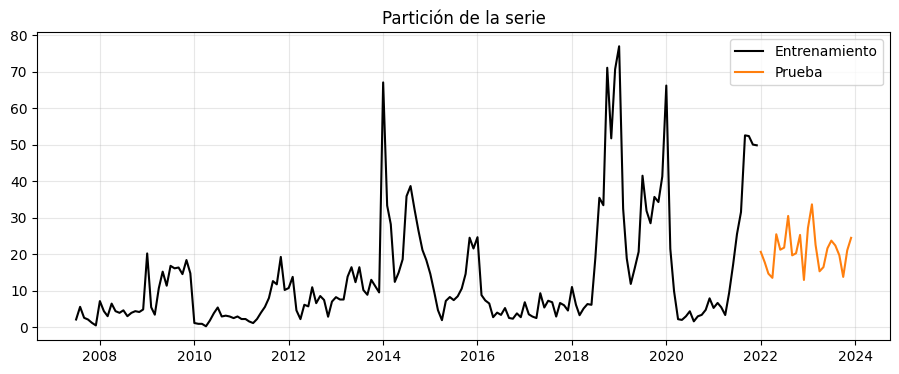

In [17]:
y_tr, y_te = y[INI:FIN_TRAIN], y[INI_TEST:]
X_tr, X_te = X[INI:FIN_TRAIN], X[INI_TEST:]
real = df["Y"][INI_TEST:]
print("Entrenamiento:", len(y_tr), "| Prueba:", len(y_te))

plt.plot(df["Y"][INI:FIN_TRAIN], color="black", label="Entrenamiento")
plt.plot(real, color="tab:orange", label="Prueba")
plt.legend(); plt.title("Partición de la serie"); plt.show()

## 6. Modelo base: SARIMA (sin clima)

SARIMA(1,0,1)(0,0,1)[12]: un término autorregresivo, uno de media móvil y uno de media móvil estacional a 12 meses.

In [18]:
ORDEN, ORDEN_EST = (1, 0, 1), (0, 0, 1, 12)
sarima = SARIMAX(y_tr, order=ORDEN, seasonal_order=ORDEN_EST).fit(disp=False, maxiter=500)
print(sarima.summary().tables[1])
print("AIC =", round(sarima.aic, 1), "| BIC =", round(sarima.bic, 1))

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9673      0.023     41.949      0.000       0.922       1.013
ma.L1         -0.1489      0.072     -2.057      0.040      -0.291      -0.007
ma.S.L12       0.1906      0.074      2.582      0.010       0.046       0.335
sigma2         0.3933      0.029     13.455      0.000       0.336       0.451
AIC = 342.6 | BIC = 355.2


## 7. SARIMAX (con clima)

Mismos órdenes, misma muestra. Lo único que cambia es el argumento `exog`.

In [19]:
sarimax = SARIMAX(y_tr, exog=X_tr, order=ORDEN, seasonal_order=ORDEN_EST).fit(disp=False, maxiter=500)
print(sarimax.summary().tables[1])
print("AIC =", round(sarimax.aic, 1), "| BIC =", round(sarimax.bic, 1))

                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
precip_lag2     0.1168      0.091      1.281      0.200      -0.062       0.296
hr_lag2         0.0253      0.005      5.594      0.000       0.016       0.034
ar.L1           0.8810      0.048     18.223      0.000       0.786       0.976
ma.L1          -0.1657      0.105     -1.575      0.115      -0.372       0.041
ma.S.L12        0.1293      0.077      1.681      0.093      -0.021       0.280
sigma2          0.3455      0.026     13.500      0.000       0.295       0.396
AIC = 322.3 | BIC = 341.3


In [20]:
b = sarimax.params["hr_lag2"]
print(f"Coeficiente de humedad relativa: {b:.4f}")
print(f"Un punto porcentual más de humedad se asocia con {100 * (np.exp(b) - 1):.1f} % más de incidencia dos meses después.")
print()
print("Ojo con la interpretación: statsmodels ajusta REGRESIÓN CON ERRORES ARMA,")
print("    log Y_t = β·X_t + u_t ,   u_t ~ ARMA(p,q)")
print("no la forma ARMAX   log Y_t = φ·log Y_{t-1} + β·X_t + ...")
print(f"Por eso β = {b:.4f} ya es el efecto total de largo plazo sobre el nivel de log(Y).")
print(f"NO hay que dividirlo por (1 - φ) = {1 - sarimax.params['ar.L1']:.3f}, que daría")
print(f"un {100 * (np.exp(b / (1 - sarimax.params['ar.L1'])) - 1):.0f} % y sería un error de más de un orden de magnitud.")

Coeficiente de humedad relativa: 0.0253
Un punto porcentual más de humedad se asocia con 2.6 % más de incidencia dos meses después.

Ojo con la interpretación: statsmodels ajusta REGRESIÓN CON ERRORES ARMA,
    log Y_t = β·X_t + u_t ,   u_t ~ ARMA(p,q)
no la forma ARMAX   log Y_t = φ·log Y_{t-1} + β·X_t + ...
Por eso β = 0.0253 ya es el efecto total de largo plazo sobre el nivel de log(Y).
NO hay que dividirlo por (1 - φ) = 0.119, que daría
un 24 % y sería un error de más de un orden de magnitud.


**Lectura.**
- La **humedad relativa** es significativa (p < 0,001).
- La **precipitación no lo es** (p ≈ 0,20). Una variable puede tener sentido biológico y no aportar al modelo una vez está la otra.
- El AIC baja unos 20 puntos: el modelo con clima ajusta mejor aun después de penalizar los dos parámetros adicionales.

### 7.1 ¿Por qué sobra la precipitación, y qué pasa si quitamos cosas?

La explicación cómoda sería colinealidad, pero hay que medirla antes de invocarla. Y como la humedad tiene tendencia (sección 3), también probamos si el coeficiente sobrevive cuando el modelo lleva su propia tendencia.

In [21]:
# ¿Colinealidad? El VIF lo dice con un número, no con una impresión.
Xc = X[INI:FIN_TRAIN].dropna()
print("Correlación entre las exógenas rezagadas:", round(Xc.corr().iloc[0, 1], 3))
Xv = sm.add_constant(Xc)
for j, col in enumerate(Xv.columns):
    if col != "const":
        print(f"  VIF {col:12s} = {variance_inflation_factor(Xv.values, j):.2f}")
print("Regla de bolsillo: VIF > 5 preocupa, VIF > 10 es grave.")

Correlación entre las exógenas rezagadas: 0.719
  VIF precip_lag2  = 2.07
  VIF hr_lag2      = 2.07
Regla de bolsillo: VIF > 5 preocupa, VIF > 10 es grave.


In [22]:
# Comparar especificaciones. BIC penaliza más que AIC los parámetros que no se ganan el puesto.
def ajustar(cols=None, trend="n"):
    xtr = X_tr[cols] if cols else None
    return SARIMAX(y_tr, exog=xtr, order=ORDEN, seasonal_order=ORDEN_EST,
                   trend=trend).fit(disp=False, maxiter=800)

filas = {}
for etiqueta, cols, tr in [
        ("SARIMA",                      None,                        "n"),
        ("SARIMA + tendencia",          None,                        "ct"),
        ("SARIMAX  humedad",            ["hr_lag2"],                 "n"),
        ("SARIMAX  humedad + lluvia",   ["precip_lag2", "hr_lag2"],  "n"),
        ("SARIMAX  humedad + tendencia", ["hr_lag2"],                "ct")]:
    r = ajustar(cols, tr)
    filas[etiqueta] = {
        "AIC": r.aic, "BIC": r.bic, "k": len(r.params),
        "β humedad": r.params.get("hr_lag2", np.nan),
        "p humedad": r.pvalues.get("hr_lag2", np.nan)}
pd.DataFrame(filas).T.round(3)

,AIC,BIC,k,β humedad,p humedad
SARIMA,342.571,355.207,4.0,NaN,NaN
SARIMA + tendencia,331.823,350.777,6.0,NaN,NaN
SARIMAX humedad,322.113,337.909,5.0,0.028,0.0
SARIMAX humedad + lluvia,322.323,341.278,6.0,0.025,0.0
SARIMAX humedad + tendencia,316.075,338.189,7.0,0.059,0.0


**Lectura.**

- **No es colinealidad.** El VIF de las dos exógenas es 2,07, muy por debajo de cualquier umbral de alarma. La precipitación no es insignificante porque la humedad "le robe" la varianza, sino porque, una vez descontada la humedad, simplemente no tiene nada que agregar. Vale la pena resistir la explicación cómoda y medir.
- **Por BIC, el mejor modelo lleva humedad sola** (337,9 contra 341,3 con las dos). AIC las empata casi exactamente (322,1 contra 322,3). Cuando dos criterios discrepan así, la lectura es que el parámetro extra no se gana el puesto: la respuesta al ejercicio 3 es que conviene quitar la precipitación.
- **El coeficiente de la humedad sobrevive, y con creces, al agregar tendencia** (0,028 → 0,059, p < 0,001 en los dos casos). No es una tendencia disfrazada.

Nota de estilo: todas estas comparaciones usan **la misma muestra de entrenamiento y la misma transformación**. AIC y BIC solo son comparables entre modelos ajustados sobre exactamente las mismas observaciones de la misma variable dependiente. Comparar el AIC de un modelo en log con el de uno en niveles es un error silencioso y frecuente.

## 8. Diagnóstico de residuos

Un buen modelo deja residuos sin patrón temporal. Revisamos tres cosas distintas, porque son fallas distintas:

| Qué se revisa | Prueba | Qué queremos |
|---|---|---|
| Autocorrelación que quedó sin modelar | Ljung-Box | p > 0,05 |
| Varianza que cambia en el tiempo | ARCH-LM | p > 0,05 |
| Normalidad (para que los intervalos sirvan) | Jarque-Bera | p > 0,05 |

Dos detalles técnicos que cambian el resultado y suelen pasarse por alto:

- Se usan los **residuos estandarizados del filtro de Kalman** (`standardized_forecasts_error`), no `resid`. En un modelo de espacio de estados los primeros residuos arrastran la inicialización difusa y tienen varianza distinta; mezclarlos sesga las pruebas. Por eso se descartan los primeros `loglikelihood_burn` más un año.
- `model_df` debe contar los parámetros **ARMA** (p + q + P + Q), no los coeficientes de las exógenas, que no consumen grados de libertad de la autocorrelación.

In [23]:
GL_ARMA = ORDEN[0] + ORDEN[2] + ORDEN_EST[0] + ORDEN_EST[2]   # p + q + P + Q

def diagnosticar(res, nombre):
    z = pd.Series(res.standardized_forecasts_error[0], index=y_tr.index)
    z = z.iloc[res.loglikelihood_burn + 12:]            # fuera la inicialización difusa
    lb = acorr_ljungbox(z, lags=[12, 24], model_df=GL_ARMA)["lb_pvalue"]
    jb, p_jb, asim, curt = res.test_normality("jarquebera")[0]
    return {"Ljung-Box 12": lb.iloc[0], "Ljung-Box 24": lb.iloc[1],
            "ARCH-LM 12": het_arch(z, nlags=12)[1],
            "Jarque-Bera": p_jb, "Asimetría": asim, "Curtosis": curt}

pd.DataFrame({"SARIMA": diagnosticar(sarima, "SARIMA"),
              "SARIMAX": diagnosticar(sarimax, "SARIMAX")}).T.round(4)

,Ljung-Box 12,Ljung-Box 24,ARCH-LM 12,Jarque-Bera,Asimetría,Curtosis
SARIMA,0.1690,0.0245,0.3860,0.0,-0.1323,6.0637
SARIMAX,0.3618,0.3187,0.4244,0.0,-0.1943,6.1141


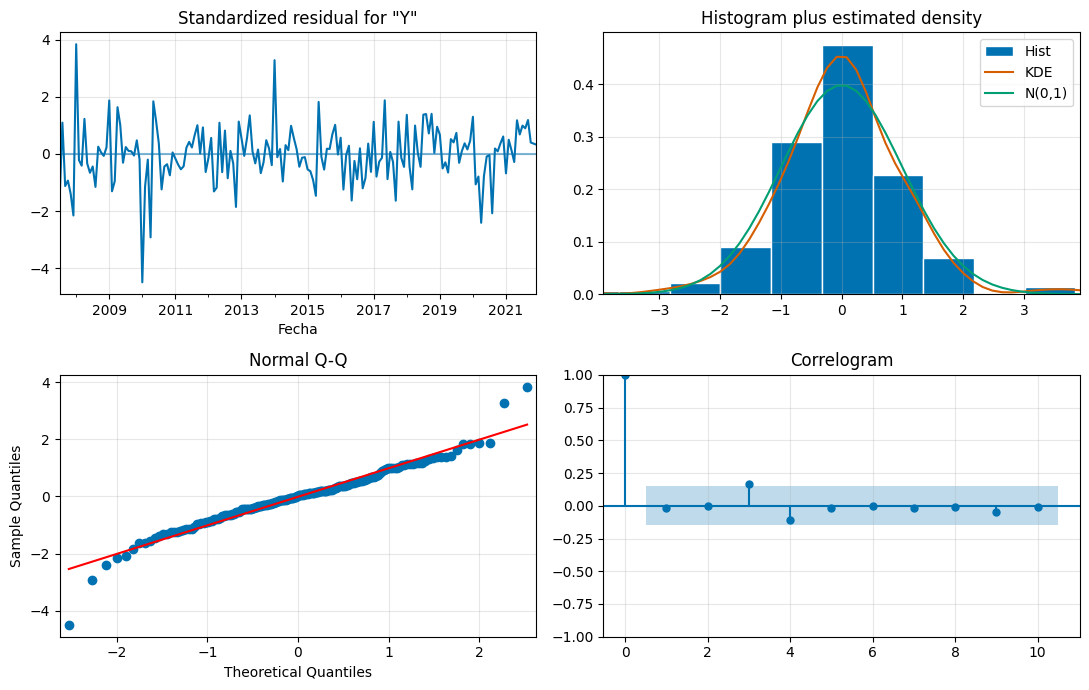

In [24]:
sarimax.plot_diagnostics(figsize=(11, 7)); plt.tight_layout(); plt.show()

**Lectura.**

- **Autocorrelación.** SARIMAX pasa en los dos horizontes (p = 0,36 y 0,32); SARIMA falla a 24 rezagos (p = 0,024). Esto sí es un argumento sólido a favor de incluir el clima: no es que pronostique mejor, es que el modelo sin clima deja estructura sin explicar.
- **Varianza.** ARCH-LM no rechaza (p ≈ 0,4) en ninguno de los dos. A pesar de los brotes, no hay volatilidad agrupada que justifique un modelo GARCH.
- **Normalidad.** Jarque-Bera rechaza con fuerza (p < 0,0001) y la curtosis es ≈ 6 contra 3 de una normal. El gráfico Q-Q lo muestra: colas pesadas por los brotes. El artículo de referencia reporta lo mismo.

**Lo que la no-normalidad sí rompe.** Los estimadores de máxima verosimilitud gaussiana siguen siendo consistentes, así que los coeficientes se pueden seguir leyendo. Lo que queda mal calibrado son los **intervalos de predicción**, que se construyen con el supuesto normal. No es un detalle cosmético: si el producto de este modelo es una alerta de vigilancia, el intervalo *es* el producto. Lo verificamos empíricamente en la sección 12.

## 9. Pronóstico en el periodo de prueba

Dos formas de evaluar:

1. **A un mes:** cada mes se pronostica con la información hasta el mes anterior, sin reestimar los parámetros. Es el uso operativo de vigilancia.
2. **A 24 meses:** un solo pronóstico hecho en diciembre de 2021, usando el clima observado. Equivale al "escenario 1" del artículo.

Los pronósticos se devuelven a la escala original con la exponencial.

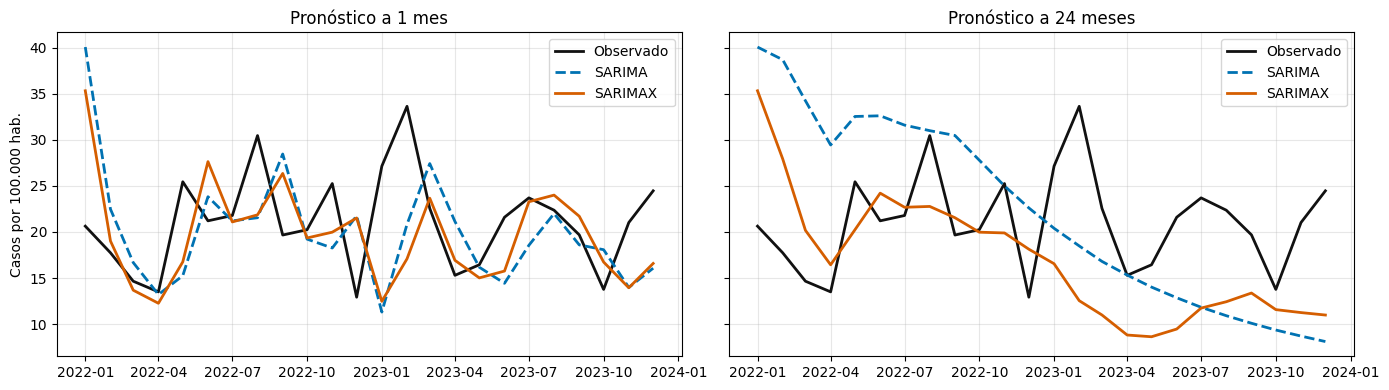

In [25]:
def pronosticar(res, exog_te):
    f24 = np.exp(res.get_forecast(24, exog=exog_te).predicted_mean)
    ext = res.append(y_te, exog=exog_te, refit=False)      # extiende el estado SIN reestimar
    f1 = np.exp(ext.get_prediction(start=INI_TEST, end=y_te.index[-1]).predicted_mean)
    return f1, f24

f1_s, f24_s = pronosticar(sarima, None)
f1_x, f24_x = pronosticar(sarimax, X_te)

fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for a, fs, fx, t in [(ax[0], f1_s, f1_x, "Pronóstico a 1 mes"),
                     (ax[1], f24_s, f24_x, "Pronóstico a 24 meses")]:
    a.plot(real, color=OBS, lw=2, label="Observado")
    a.plot(fs, color=PAL[0], ls="--", lw=2, label="SARIMA")
    a.plot(fx, color=PAL[1], ls="-", lw=2, label="SARIMAX")
    a.set_title(t); a.legend()
ax[0].set_ylabel("Casos por 100.000 hab.")
plt.tight_layout(); plt.show()

In [26]:
# Escala del MASE: el MAE de un pronóstico estacional ingenuo DENTRO DEL ENTRENAMIENTO.
# Al ser una constante fija, el MASE es comparable entre horizontes, modelos y municipios.
ESCALA_MASE = df["Y"][INI:FIN_TRAIN].diff(12).abs().mean()

def metricas(a, f):
    e = a - f
    return {"RMSE": np.sqrt((e ** 2).mean()),
            "MAE": e.abs().mean(),
            "MAPE (%)": (e.abs() / a).mean() * 100,
            "sMAPE (%)": (200 * e.abs() / (a.abs() + f.abs())).mean(),
            "MASE": e.abs().mean() / ESCALA_MASE}

print(f"Escala del MASE (MAE del estacional ingenuo en entrenamiento) = {ESCALA_MASE:.2f} casos/100.000")

tabla = pd.DataFrame({
    ("1 mes", "SARIMA"): metricas(real, f1_s),   ("1 mes", "SARIMAX"): metricas(real, f1_x),
    ("24 meses", "SARIMA"): metricas(real, f24_s), ("24 meses", "SARIMAX"): metricas(real, f24_x),
}).round(2)
tabla

Escala del MASE (MAE del estacional ingenuo en entrenamiento) = 13.26 casos/100.000


1 mes         24 meses        
          SARIMA SARIMAX   SARIMA SARIMAX
RMSE        7.89    7.12    11.54    9.18
MAE         6.15    5.31     9.92    7.76
MAPE (%)   28.60   24.07    50.81   36.18
sMAPE (%)  28.72   24.93    47.19   41.89
MASE        0.46    0.40     0.75    0.59

**Lectura, y es la conclusión que el resto del notebook va a poner a prueba.**

- SARIMAX gana en todas las métricas y en los dos horizontes.
- La ganancia es mayor a 24 meses. Sin exógenas, un pronóstico largo solo puede volver a la media; el clima sigue aportando información.
- Un MAPE cercano a 24 % a un mes no es un pronóstico preciso. Ningún modelo anticipa bien los saltos bruscos.

**Tres preguntas que esta tabla no responde**, y que son las que separan un ejercicio de clase de un informe defendible:

1. **MAPE y sMAPE no son intercambiables.** El MAPE castiga más la sobreestimación que la subestimación y se dispara cuando el observado es pequeño, justo en los meses de incidencia baja que abundan aquí. El sMAPE es simétrico pero tiene sus propias patologías. Ninguno de los dos dice si el modelo es *útil*: para eso hace falta compararlo con algo. → sección 10.
2. **`np.exp(predicted_mean)` no devuelve el pronóstico medio.** Devuelve la **mediana**. Esa distinción cambia el RMSE a 24 meses de 11,5 a 52,9 en uno de los modelos. → sección 11.
3. **Estos números salen de una sola partición.** → secciones 14 y 15.

## 10. ¿Le ganamos a algo trivial? Benchmarks y MASE

Decir "SARIMAX tiene RMSE de 7,1" no informa nada por sí solo. ¿7,1 es bueno? La única forma de saberlo es comparar contra pronósticos que no requieren ningún modelo:

| Benchmark | Regla | Para qué sirve |
|---|---|---|
| **Ingenuo** | el pronóstico es el último valor observado | piso para horizontes cortos |
| **Estacional ingenuo** | el pronóstico es el valor del mismo mes del año pasado | piso para series con ciclo anual |
| **Climatología** | el pronóstico es el promedio histórico de ese mes | piso para series estacionales con ruido |

Y para comparar entre horizontes usamos el **MASE** (Hyndman & Koehler, 2006):

$$\text{MASE} = \frac{\text{MAE del modelo}}{\text{MAE del estacional ingenuo en el entrenamiento}}$$

Se lee directo: **MASE < 1 significa mejor que el estacional ingenuo; MASE > 1, peor.** El denominador es una constante calculada una sola vez con el entrenamiento, así que el MASE sí es comparable entre horizontes y entre municipios, cosa que el RMSE y el MAPE no son.

**Un detalle que invalida resultados si se descuida.** Para el pronóstico a 24 meses hecho en diciembre de 2021, el estacional ingenuo de 2023 **no puede** usar los valores observados de 2022: en diciembre de 2021 no existían. Hay que repetir el último ciclo disponible. Escribir `y.shift(12)` para todo el periodo de prueba es una fuga de información que mejora artificialmente el benchmark y hace quedar mal al modelo.

In [27]:
def snaive_origen(origen, h):
    """Estacional ingenuo SIN fuga: desde `origen` solo usa el último ciclo disponible."""
    hist = df["Y"][:origen]
    idx = pd.date_range(origen + pd.DateOffset(months=1), periods=h, freq="MS")
    vals = [hist.loc[origen + pd.DateOffset(months=k)
                     - pd.DateOffset(months=12 * int(np.ceil(k / 12)))]
            for k in range(1, h + 1)]
    return pd.Series(vals, index=idx)

ORIGEN_FIJO = pd.Timestamp(FIN_TRAIN + "-01")

# A 1 mes: en el mes t sí se conocen y_{t-1} e y_{t-12}.
b1_ingenuo = df["Y"].shift(1)[INI_TEST:]
b1_estac = df["Y"].shift(12)[INI_TEST:]

# A 24 meses: todo debe salir de la información disponible en diciembre de 2021.
b24_ingenuo = pd.Series(df["Y"][:FIN_TRAIN].iloc[-1], index=real.index)
b24_estac = snaive_origen(ORIGEN_FIJO, 24)

# Climatología: promedio por mes calendario, estimado SOLO con el entrenamiento.
normales = df["Y"][INI:FIN_TRAIN].groupby(df["Y"][INI:FIN_TRAIN].index.month).mean()
b_clima = pd.Series(normales.reindex(real.index.month).values, index=real.index)

print("Fuga que se evita:  MASE del estacional ingenuo a 24 meses")
print(f"   con y.shift(12)  (CON fuga) = {metricas(real, b1_estac)['MASE']:.2f}   <-- demasiado bueno")
print(f"   con el último ciclo (correcto) = {metricas(real, b24_estac)['MASE']:.2f}")

Fuga que se evita:  MASE del estacional ingenuo a 24 meses
   con y.shift(12)  (CON fuga) = 0.85   <-- demasiado bueno
   con el último ciclo (correcto) = 1.33


In [28]:
tabla_bm = pd.DataFrame({
    ("1 mes", "Ingenuo"):          metricas(real, b1_ingenuo),
    ("1 mes", "Estacional ing."):  metricas(real, b1_estac),
    ("1 mes", "Climatología"):     metricas(real, b_clima),
    ("1 mes", "SARIMA"):           metricas(real, f1_s),
    ("1 mes", "SARIMAX"):          metricas(real, f1_x),
    ("24 meses", "Ingenuo"):         metricas(real, b24_ingenuo),
    ("24 meses", "Estacional ing."): metricas(real, b24_estac),
    ("24 meses", "Climatología"):    metricas(real, b_clima),
    ("24 meses", "SARIMA"):          metricas(real, f24_s),
    ("24 meses", "SARIMAX"):         metricas(real, f24_x),
}).T.round(2)
tabla_bm

RMSE    MAE  MAPE (%)  sMAPE (%)  MASE
1 mes    Ingenuo           9.05   6.61     32.42      29.09  0.50
         Estacional ing.  15.32  11.31     59.24      52.72  0.85
         Climatología     10.04   8.71     40.95      53.68  0.66
         SARIMA            7.89   6.15     28.60      28.72  0.46
         SARIMAX           7.12   5.31     24.07      24.93  0.40
24 meses Ingenuo          29.23  28.78    151.60      82.66  2.17
         Estacional ing.  21.20  17.66     91.87      79.85  1.33
         Climatología     10.04   8.71     40.95      53.68  0.66
         SARIMA           11.54   9.92     50.81      47.19  0.75
         SARIMAX           9.18   7.76     36.18      41.89  0.59

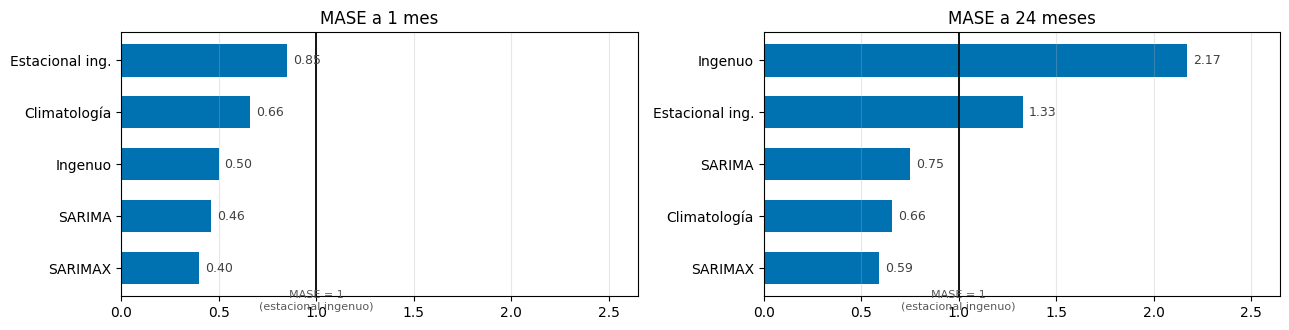

In [29]:
# El MASE es una sola magnitud por modelo: barras, un solo tono, y el valor escrito al lado.
mase = tabla_bm["MASE"].unstack(0)[["1 mes", "24 meses"]]
fig, ax = plt.subplots(1, 2, figsize=(13, 3.4), sharex=True)
for a, col in zip(ax, mase.columns):
    s = mase[col].sort_values()
    a.barh(s.index, s.values, color=PAL[0], height=0.62)
    a.axvline(1.0, color=OBS, lw=1.4)
    a.annotate("MASE = 1\n(estacional ingenuo)", xy=(1.0, -0.42), fontsize=8,
               color="0.35", ha="center", va="top")
    for nombre, v in s.items():
        a.text(v + 0.03, nombre, f"{v:.2f}", va="center", fontsize=9, color="0.25")
    a.set_title(f"MASE a {col}"); a.set_xlim(0, max(mase.max()) * 1.22)
    a.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

**Lectura, y el aire se empieza a ir del globo.**

- **A 1 mes, el pronóstico ingenuo tiene MASE 0,50 y SARIMAX 0,40.** Los modelos ganan, sí, pero la mejora sobre "repetir el último valor" es del orden del 20 %. Eso es mucho menos impresionante que decir "RMSE 7,1" sin contexto. Y nótese que el ingenuo (0,50) le gana al estacional ingenuo (0,85): con Fs = 0,35, el mes anterior informa más que el mismo mes del año pasado.
- **A 24 meses, la climatología tiene MASE 0,66 y SARIMA 0,75.** La climatología —el promedio histórico de cada mes, cero parámetros estimados— **le gana al SARIMA**. SARIMAX (0,59) le gana a la climatología, pero por un margen modesto.
- **El estacional ingenuo, bien calculado, es malísimo** (MASE 1,33 a 24 meses). Con la fuga de `y.shift(12)` habría dado 0,85 y habría parecido competitivo. Media línea de código, conclusión distinta.

**La regla de oficio.** Un modelo de pronóstico no se reporta nunca sin al menos un benchmark trivial al lado. Si el artículo que estamos adaptando hubiera incluido la climatología en su tabla, la lectura de sus resultados habría sido otra. No es un defecto de ese artículo en particular: es la norma en buena parte de la literatura aplicada.

## 11. Volver de log a casos: ¿`exp` da la media o la mediana?

Modelamos log(Y) y pronosticamos con `np.exp(predicted_mean)`. Parece inocuo y no lo es.

Si log(Y) tiene distribución normal con media μ y varianza σ², entonces Y es lognormal y:

$$\text{mediana}(Y) = e^{\mu}, \qquad \mathbb{E}[Y] = e^{\mu + \sigma^2/2}$$

Como σ² > 0 siempre, **`np.exp(predicted_mean)` es la mediana, nunca la media**, y queda sistemáticamente por debajo del valor esperado. El factor de corrección es $e^{\sigma_h^2/2}$ y crece con el horizonte, porque σ_h crece con h.

Cuál de los dos se quiere depende de para qué:

| Lo que se busca | Pronóstico puntual óptimo | Transformación |
|---|---|---|
| Minimizar el **MAE** | la mediana | `exp(μ̂)` |
| Minimizar el **ECM** | la media | `exp(μ̂ + σ̂²/2)` |
| **Sumar** o agregar (casos del año, presupuesto) | la media | `exp(μ̂ + σ̂²/2)` |

La tercera fila es la que suele doler en la práctica: si se suman 12 medianas mensuales para estimar el total anual, el total queda subestimado, y el error no se cancela.

Los **cuantiles sí se transforman exactamente** (porque `exp` es monótona creciente), así que los extremos de un intervalo de predicción no necesitan ninguna corrección. Solo la media la necesita.

In [30]:
ext_s = sarima.append(y_te, refit=False)
ext_x = sarimax.append(y_te, exog=X_te, refit=False)
predicciones = {
    ("1 mes", "SARIMA"):   ext_s.get_prediction(start=INI_TEST, end=y_te.index[-1]),
    ("1 mes", "SARIMAX"):  ext_x.get_prediction(start=INI_TEST, end=y_te.index[-1]),
    ("24 meses", "SARIMA"):  sarima.get_forecast(24),
    ("24 meses", "SARIMAX"): sarimax.get_forecast(24, exog=X_te),
}

a_mediana = lambda p: np.exp(p.predicted_mean)
a_media = lambda p: np.exp(p.predicted_mean + 0.5 * p.se_mean ** 2)

filas = {}
for clave, p in predicciones.items():
    filas[clave] = {
        "σ del último paso": p.se_mean.iloc[-1],
        "factor exp(σ²/2)": float(np.exp(0.5 * p.se_mean.iloc[-1] ** 2)),
        "RMSE mediana": metricas(real, a_mediana(p))["RMSE"],
        "RMSE media":   metricas(real, a_media(p))["RMSE"],
        "MAE mediana":  metricas(real, a_mediana(p))["MAE"],
        "MAE media":    metricas(real, a_media(p))["MAE"]}
pd.DataFrame(filas).T.round(2)

σ del último paso  factor exp(σ²/2)  RMSE mediana  \
1 mes    SARIMA                0.63              1.22          7.89   
         SARIMAX               0.59              1.19          7.12   
24 meses SARIMA                2.08              8.68         11.54   
         SARIMAX               1.10              1.83          9.18   

                  RMSE media  MAE mediana  MAE media  
1 mes    SARIMA         9.43         6.15       7.48  
         SARIMAX        8.04         5.31       6.43  
24 meses SARIMA        52.94         9.92      51.97  
         SARIMAX       10.83         7.76       8.63

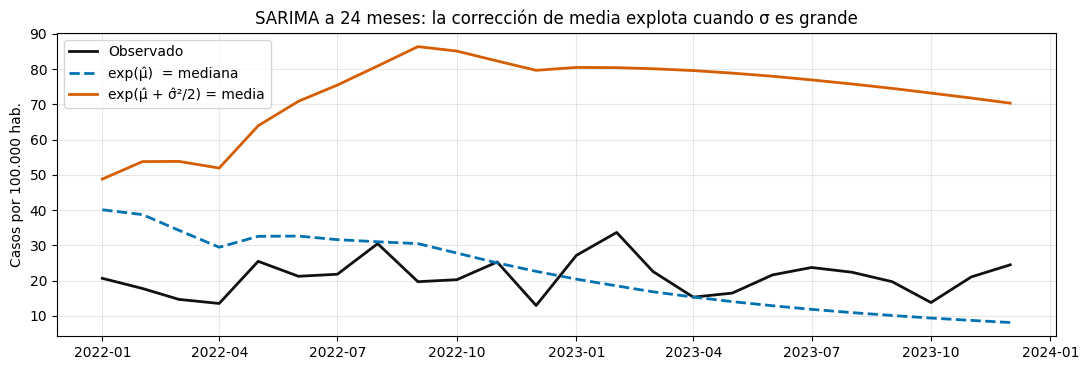

In [31]:
p = predicciones[("24 meses", "SARIMA")]
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(real, color=OBS, lw=2, label="Observado")
ax.plot(a_mediana(p), color=PAL[0], ls="--", lw=2, label="exp(μ̂)  = mediana")
ax.plot(a_media(p),  color=PAL[1], ls="-",  lw=2, label="exp(μ̂ + σ̂²/2) = media")
ax.set_title("SARIMA a 24 meses: la corrección de media explota cuando σ es grande")
ax.set_ylabel("Casos por 100.000 hab."); ax.legend()
plt.tight_layout(); plt.show()

**Lectura, y es una trampa con dientes.**

- A 1 paso el factor de corrección es 1,19–1,22: un 20 % de diferencia, nada despreciable pero manejable.
- A 24 pasos, el σ del SARIMA en escala log llega a **2,08** y el factor de corrección a **8,68**. El RMSE pasa de 11,5 (mediana) a **52,9** (media). El pronóstico "correcto en media" se vuelve inservible.
- El SARIMAX aguanta mucho mejor (σ = 1,10, factor 1,83, RMSE de 9,2 a 10,8) justo porque las exógenas le recortan la varianza del pronóstico largo.

**Lo que esto revela no es que la corrección esté mal, sino que el modelo está mal.** El factor $e^{\sigma_h^2/2}$ solo es la media correcta si los residuos en log son realmente normales. En la sección 8 Jarque-Bera rechazó la normalidad con curtosis ≈ 6. La corrección amplifica ese error de especificación hasta hacerlo visible. Es, a su manera, un diagnóstico: **si la corrección de media explota, el supuesto distribucional no aguanta ese horizonte.**

**Qué hacer en la práctica:**

1. Si se reportan pronósticos puntuales y se evalúan con MAE o MASE, `exp(μ̂)` está bien, pero hay que **decir que es la mediana**.
2. Si hay que agregar o sumar, usar la corrección en horizontes cortos y, para horizontes largos, no confiar en el supuesto lognormal: estimar la media por simulación desde la distribución empírica de los residuos (*bootstrap* de trayectorias).
3. Nunca mezclar: comparar la mediana de un modelo con la media de otro invalida la tabla.

En el resto del notebook seguimos usando `exp(μ̂)` —la mediana— y ya queda dicho.

## 12. Intervalos de predicción: ¿sirven para decidir algo?

En vigilancia epidemiológica el producto casi nunca es el número puntual, sino la **banda**: "se esperan entre 8 y 25 casos por 100.000; si se superan 25, se activa el protocolo". Entonces el intervalo hay que evaluarlo, no solo dibujarlo.

Un intervalo se juzga por dos cosas a la vez, y hay que mirar las dos:

- **Cobertura.** De los 24 meses de prueba, ¿cuántos cayeron dentro del intervalo al 80 %? Debería ser cerca del 80 %. Más es sobrecobertura, menos es sobreconfianza.
- **Amplitud.** Un intervalo de 0 a infinito tiene cobertura perfecta y valor nulo. La cobertura solo significa algo junto a la amplitud.

Con 24 observaciones la cobertura se estima con mucho ruido (el error estándar de una proporción de 0,8 con n = 24 es ±8 puntos), así que esto es un chequeo de orden de magnitud, no una calibración fina.

In [32]:
filas = {}
for clave, p in predicciones.items():
    fila = {}
    for alpha in (0.20, 0.05):
        ic = np.exp(p.conf_int(alpha=alpha))          # los cuantiles sí se transforman exactos
        lo, hi = ic.iloc[:, 0].values, ic.iloc[:, 1].values
        nivel = int((1 - alpha) * 100)
        fila[f"cobertura {nivel}% (%)"] = ((real.values >= lo) & (real.values <= hi)).mean() * 100
        fila[f"amplitud media {nivel}%"] = (hi - lo).mean()
    filas[clave] = fila
cobertura = pd.DataFrame(filas).T.round(1)
print(f"Nivel nominal 80 % y 95 %. Media de la serie observada en prueba: {real.mean():.1f}")
cobertura

Nivel nominal 80 % y 95 %. Media de la serie observada en prueba: 21.1


cobertura 80% (%)  amplitud media 80%  cobertura 95% (%)  \
1 mes    SARIMA                95.8                35.8              100.0   
         SARIMAX               95.8                32.5              100.0   
24 meses SARIMA               100.0               143.6              100.0   
         SARIMAX              100.0                54.0              100.0   

                  amplitud media 95%  
1 mes    SARIMA                 62.6  
         SARIMAX                56.0  
24 meses SARIMA                441.1  
         SARIMAX               112.9

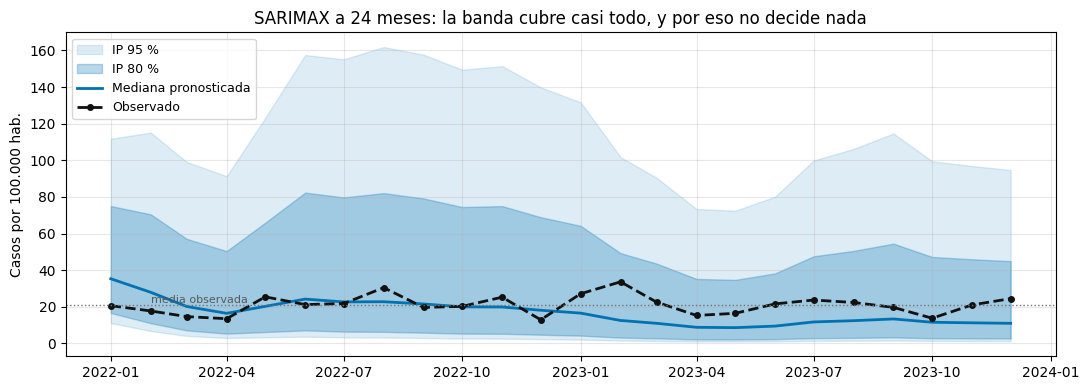

In [33]:
p = predicciones[("24 meses", "SARIMAX")]
ic80, ic95 = np.exp(p.conf_int(alpha=0.20)), np.exp(p.conf_int(alpha=0.05))

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(ic95.index, ic95.iloc[:, 0], ic95.iloc[:, 1], color=PAL[0], alpha=0.13, label="IP 95 %")
ax.fill_between(ic80.index, ic80.iloc[:, 0], ic80.iloc[:, 1], color=PAL[0], alpha=0.28, label="IP 80 %")
ax.plot(a_mediana(p), color=PAL[0], lw=2, label="Mediana pronosticada")
ax.plot(real, color=OBS, lw=2, ls="--", marker="o", ms=4, label="Observado")
ax.axhline(real.mean(), color="0.45", lw=1, ls=":")
ax.annotate("media observada", xy=(real.index[1], real.mean()), fontsize=8, color="0.35", va="bottom")
ax.set_title("SARIMAX a 24 meses: la banda cubre casi todo, y por eso no decide nada")
ax.set_ylabel("Casos por 100.000 hab."); ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

**Lectura, y el problema no es el que uno esperaría.**

En la sección 8 vimos colas pesadas, así que lo natural sería temer intervalos **demasiado estrechos**. Pasa lo contrario: los intervalos están **demasiado anchos**. El nominal de 80 % cubre el 96 % de los meses y el de 95 % cubre el 100 %.

Y las amplitudes son las que condenan el ejercicio. La banda al 80 % del SARIMAX a 24 meses mide en promedio **54 casos por 100.000**, sobre un periodo de prueba cuya media observada es 21 (y cuya serie completa promedia 14). El intervalo abarca desde "año tranquilo" hasta "epidemia grande". Es un intervalo honesto y completamente inútil para activar un protocolo. El del SARIMA es aún peor: 144 al 80 % y 441 al 95 %.

**La lección es la que más cuesta aceptar:** la sobrecobertura no es un error de programación que se pueda arreglar, es el modelo diciendo la verdad sobre cuánto *no* sabe. σ en escala log vale ≈ 1,1 a 24 meses, y en escala multiplicativa eso significa un factor de 3 hacia arriba y hacia abajo. Un modelo con R² bajo sobre una serie de brotes no puede producir bandas angostas sin mentir.

**Qué sí se puede hacer con esto:**

- Reportar la banda junto al punto, siempre, para que quede claro el tamaño de la incertidumbre.
- Dejar de evaluar solo el punto. Las reglas de puntaje propias para distribuciones (*interval score*, CRPS, puntaje logarítmico) penalizan la amplitud y la falta de cobertura a la vez, y son el estándar en los retos de pronóstico de enfermedades (FluSight, los *dengue forecasting challenges*).
- Cambiar la pregunta operativa. En vez de "¿cuántos casos habrá en 18 meses?" —que este modelo no puede contestar— preguntar "¿cuál es la probabilidad de superar el umbral epidémico en los próximos 2 meses?", que es una pregunta a horizonte corto y con respuesta probabilística.

## 13. Pronóstico *ex ante*: ¿y si no conocemos el clima futuro?

El pronóstico a 24 meses de la sección 9 le pasó al modelo `X_te`, es decir, **el clima realmente observado en 2022 y 2023**. En diciembre de 2021 esa información no existía.

Con rezago 2, al pronosticar desde diciembre de 2021 el clima está disponible para enero y febrero de 2022 (usan el clima de noviembre y diciembre de 2021). **De marzo de 2022 en adelante hay que inventarlo.** Ese era el ejercicio 6 del notebook; lo resolvemos aquí.

La distinción tiene nombres establecidos y conviene usarlos:

- **Pronóstico *ex post*** (o "escenario"): usa valores observados de las exógenas. Responde "¿qué habría dicho el modelo si hubiera conocido el clima?". Es una herramienta válida para atribución y para escenarios, **no** es un pronóstico.
- **Pronóstico *ex ante***: usa solo información disponible en el momento del pronóstico. Es lo único que se puede ofrecer a quien tiene que decidir.

Para el clima más allá de dos meses usamos **normales climatológicas**: el promedio de cada mes calendario estimado con el entrenamiento. Es lo que haría cualquier oficina de vigilancia que no tenga acceso a pronósticos estacionales.

In [34]:
CLIMA = list(X.columns)

def exog_ex_ante(Xf, origen, h):
    """Exógenas disponibles en `origen`: con rezago 2 los dos primeros pasos son reales;
    de ahí en adelante, normales climatológicas estimadas solo con el pasado."""
    if Xf is None:
        return None
    idx = pd.date_range(origen + pd.DateOffset(months=1), periods=h, freq="MS")
    Xr = Xf.reindex(idx).copy()
    cols = [c for c in Xr.columns if c in CLIMA]
    if cols and h > 2:
        normales = Xf[:origen].groupby(Xf[:origen].index.month).mean()
        for c in cols:
            Xr.loc[idx[2:], c] = normales.loc[idx[2:].month, c].values
    return Xr

X_ante = exog_ex_ante(X, ORIGEN_FIJO, 24)
print("Clima que usa el pronóstico ex ante (las dos primeras filas son reales):")
print(X_ante.head(4).round(2).to_string())

f24_ante = np.exp(sarimax.get_forecast(24, exog=X_ante).predicted_mean)
pd.DataFrame({
    "Estacional ing.":          metricas(real, b24_estac),
    "Climatología":             metricas(real, b_clima),
    "SARIMA":                   metricas(real, f24_s),
    "SARIMAX ex post (clima observado)": metricas(real, f24_x),
    "SARIMAX ex ante (normales)":        metricas(real, f24_ante),
}).T.round(2)

Clima que usa el pronóstico ex ante (las dos primeras filas son reales):
            precip_lag2  hr_lag2
2022-01-01         1.06    85.40
2022-02-01         0.41    83.30
2022-03-01         0.21    79.14
2022-04-01         0.15    73.27


,RMSE,MAE,MAPE (%),sMAPE (%),MASE
Estacional ing.,21.20,17.66,91.87,79.85,1.33
Climatología,10.04,8.71,40.95,53.68,0.66
SARIMA,11.54,9.92,50.81,47.19,0.75
SARIMAX ex post (clima observado),9.18,7.76,36.18,41.89,0.59
SARIMAX ex ante (normales),8.72,7.46,34.84,39.09,0.56


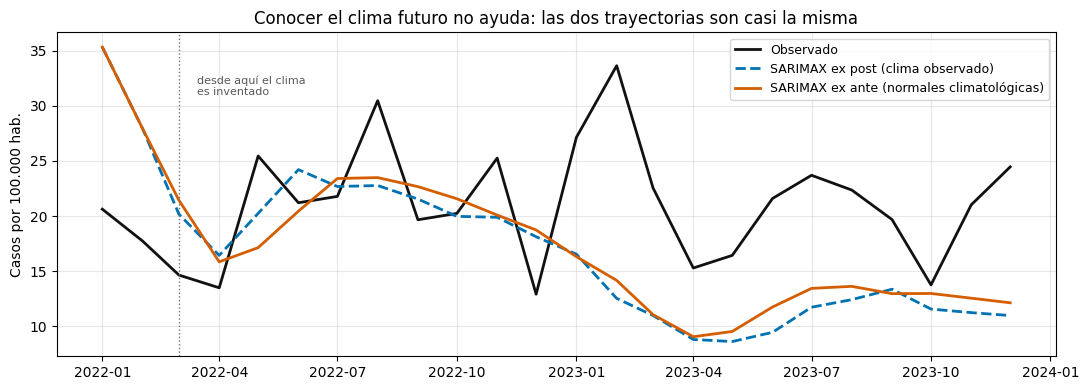

In [35]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(real, color=OBS, lw=2, label="Observado")
ax.plot(f24_x,    color=PAL[0], ls="--", lw=2, label="SARIMAX ex post (clima observado)")
ax.plot(f24_ante, color=PAL[1], ls="-",  lw=2, label="SARIMAX ex ante (normales climatológicas)")
ax.axvline(pd.Timestamp("2022-03-01"), color="0.45", lw=1, ls=":")
ax.annotate("desde aquí el clima\nes inventado", xy=(pd.Timestamp("2022-03-15"), real.max() * 0.92),
            fontsize=8, color="0.35")
ax.set_title("Conocer el clima futuro no ayuda: las dos trayectorias son casi la misma")
ax.set_ylabel("Casos por 100.000 hab."); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**Lectura, y es contraintuitiva en el mejor sentido.**

El pronóstico *ex ante* no es peor que el *ex post*: es **ligeramente mejor** (RMSE 8,72 contra 9,18; MASE 0,56 contra 0,59). Sustituir el clima observado por su promedio histórico no le quita nada al modelo.

Esto es una buena noticia operativa y un diagnóstico incómodo a la vez:

- **Buena noticia.** No hace falta pronosticar el clima para usar este SARIMAX a horizontes largos. Basta con las normales climatológicas. El ejercicio 6 tiene una respuesta tranquilizadora.
- **Diagnóstico incómodo.** Si el promedio histórico del clima funciona igual que el clima real, entonces **lo que el modelo está usando del clima es su parte predecible, es decir, el ciclo anual**, y no las anomalías de cada año. Las desviaciones respecto a lo normal —un año excepcionalmente húmedo, un Niño— no están aportando nada.

Y si lo único que aporta el clima es un ciclo anual, uno podría generar ese ciclo sin ningún dato climático. Esa es exactamente la hipótesis que prueba la sección 16.

*(Por qué el ex ante sale apenas mejor y no igual: las normales son más suaves que el clima observado, y suavizar un regresor cuyo coeficiente está estimado con ruido reduce la varianza del pronóstico. No es que inventar sea mejor que saber; es que la señal era tan débil que el ruido del dato real costaba más de lo que valía.)*

## 14. Validación de origen rodante: ¿el resultado aguanta más de una partición?

Todo lo anterior salió de **una** partición: entrenar hasta diciembre de 2021, probar 2022–2023. Si esos dos años resultaron ser favorables al SARIMAX por casualidad, no hay forma de saberlo con una sola partición.

La solución estándar en series de tiempo no es la validación cruzada en k pliegues —que rompe el orden temporal y mezcla futuro con pasado— sino la **validación de origen rodante** (*rolling-origin*, o *time-series cross-validation*):

1. Se fija un origen de pronóstico.
2. Se **reestima el modelo** con todo lo anterior a ese origen, y nada más.
3. Se pronostica h = 1, 2, …, 6 pasos y se guardan los errores.
4. Se avanza el origen y se repite.

Tres decisiones que hay que tomar explícitamente, porque cambian el resultado:

- **Reestimar en cada origen.** Es más lento, pero es lo honesto: en operación real uno reajusta el modelo cuando llegan datos nuevos. Fijar los parámetros de 2021 y aplicarlos a 2016 es mirar al futuro.
- **Exógenas *ex ante*.** Usamos `exog_ex_ante` de la sección 13 en todos los orígenes. Si usáramos el clima observado, estaríamos evaluando un escenario, no un pronóstico.
- **Ventana expansiva, no deslizante.** Con 174 meses de entrenamiento inicial hay poco que ganar descartando los años viejos, y el dengue no cambió de régimen de forma obvia.

Aquí usamos 27 orígenes trimestrales entre diciembre de 2016 y junio de 2023, con h hasta 6 meses. **La celda tarda alrededor de medio minuto**: 27 orígenes × 3 modelos = 81 reestimaciones.

In [36]:
H_MAX, PASO = 6, 3
ORIGENES = pd.date_range("2016-12-01", "2023-06-01", freq=f"{PASO}MS")

MODELOS = {
    "SARIMA":        dict(exog=None, orden=(1, 0, 1), est=(0, 0, 1, 12)),
    "SARIMAX clima": dict(exog=X,    orden=(1, 0, 1), est=(0, 0, 1, 12)),
}

def backtest(modelos, origenes=ORIGENES, h_max=H_MAX):
    """Origen rodante con reestimación en cada origen y exógenas ex ante."""
    partes = []
    for org in origenes:
        h = min(h_max, len(df.loc[org + pd.DateOffset(months=1):]))
        if h < 1:
            continue
        idx = pd.date_range(org + pd.DateOffset(months=1), periods=h, freq="MS")
        fila = {"origen": org, "h": np.arange(1, h + 1),
                "obs": df["Y"].reindex(idx).values,
                "Estacional ing.": snaive_origen(org, h).values}
        for nombre, cfg in modelos.items():
            Xf = cfg["exog"]
            r = SARIMAX(y[INI:org], exog=(Xf[INI:org] if Xf is not None else None),
                        order=cfg["orden"], seasonal_order=cfg["est"]).fit(disp=False, maxiter=500)
            fila[nombre] = np.exp(
                r.get_forecast(h, exog=exog_ex_ante(Xf, org, h)).predicted_mean).values
        partes.append(pd.DataFrame(fila))
    return pd.concat(partes, ignore_index=True).set_index(["origen", "h"])

bt = backtest(MODELOS)
print(f"{len(ORIGENES)} orígenes, {len(bt)} pronósticos evaluados, "
      f"h de 1 a {H_MAX} meses, desde {ORIGENES[0].date()} hasta {ORIGENES[-1].date()}")
bt.head(8).round(2)

27 orígenes, 162 pronósticos evaluados, h de 1 a 6 meses, desde 2016-12-01 hasta 2023-06-01


obs  Estacional ing.  SARIMA  SARIMAX clima
origen     h                                              
2016-12-01 1  6.81            24.64    2.83           3.35
           2  3.51             8.77    2.39           3.48
           3  2.89             7.31    2.30           2.98
           4  2.48             6.47    2.23           2.93
           5  9.29             2.72    1.88           3.16
           6  5.37             3.97    1.93           4.29
2017-03-01 1  2.48             6.47    2.91           2.70
           2  9.29             2.72    2.38           3.23

In [37]:
def resumen_backtest(tabla, modelos):
    out = {}
    for m in modelos:
        e = tabla["obs"] - tabla[m]
        out[m] = {"RMSE": np.sqrt((e ** 2).mean()), "MAE": e.abs().mean(),
                  "MASE": e.abs().mean() / ESCALA_MASE}
    return pd.DataFrame(out).T

COLS = ["Estacional ing.", "SARIMA", "SARIMAX clima"]
print("Agregado sobre los 162 pronósticos (h = 1 a 6):")
resumen_backtest(bt, COLS).round(2)

Agregado sobre los 162 pronósticos (h = 1 a 6):


,RMSE,MAE,MASE
Estacional ing.,24.38,17.45,1.32
SARIMA,17.65,11.85,0.89
SARIMAX clima,16.88,10.25,0.77


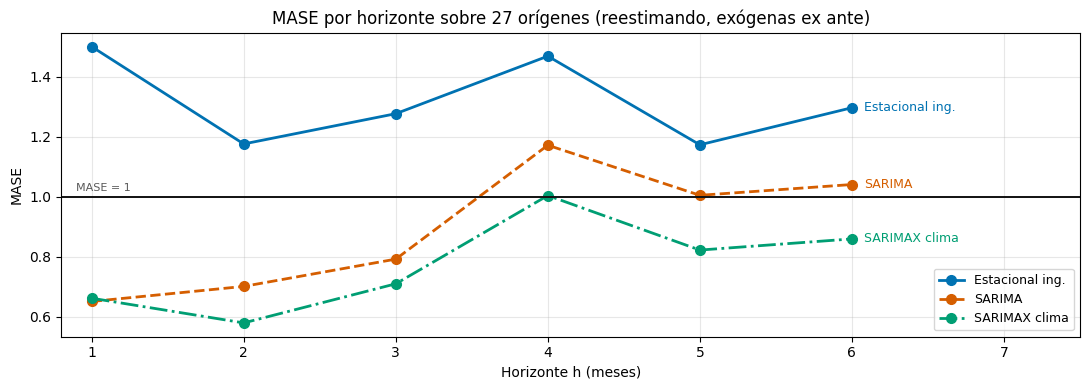

,Estacional ing.,SARIMA,SARIMAX clima
h,,,
1,1.50,0.65,0.66
2,1.18,0.70,0.58
3,1.28,0.79,0.71
4,1.47,1.17,1.00
5,1.17,1.00,0.82
6,1.30,1.04,0.86


In [38]:
def mase_por_horizonte(tabla, modelos):
    err = tabla.assign(**{m: (tabla["obs"] - tabla[m]).abs() / ESCALA_MASE for m in modelos})
    return err.groupby(level="h")[modelos].mean()

mase_h = mase_por_horizonte(bt, COLS)

fig, ax = plt.subplots(figsize=(11, 4))
ESTILOS = ["-", "--", "-."]
for (m, serie), color, estilo in zip(mase_h.items(), PAL, ESTILOS):
    ax.plot(serie.index, serie.values, color=color, ls=estilo, lw=2, marker="o", ms=7, label=m)
    ax.annotate(m, xy=(serie.index[-1] + 0.08, serie.values[-1]), color=color, fontsize=9, va="center")
ax.axhline(1.0, color=OBS, lw=1.4)
ax.annotate("MASE = 1", xy=(0.9, 1.02), fontsize=8, color="0.35")
ax.set_xlabel("Horizonte h (meses)"); ax.set_ylabel("MASE")
ax.set_title("MASE por horizonte sobre 27 orígenes (reestimando, exógenas ex ante)")
ax.set_xlim(0.8, H_MAX + 1.5); ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.show()

mase_h.round(2)

**Lectura, y aquí la conclusión de la sección 9 se parte en dos.**

| Horizonte | SARIMA | SARIMAX clima | ¿Gana el clima? |
|---|---|---|---|
| 1 mes | 0,65 | 0,66 | **no** |
| 2 meses | 0,70 | 0,58 | sí |
| 3 meses | 0,79 | 0,71 | sí |
| 6 meses | 1,04 | 0,86 | sí, con claridad |

- **A un mes el clima no aporta nada.** SARIMA 0,65 contra SARIMAX 0,66: empate, con ventaja nominal para el modelo *sin* clima. La partición única de la sección 9 había dado 7,89 contra 7,12 a favor del SARIMAX; sobre 27 orígenes esa ventaja desaparece. Era ruido de una sola realización.
- **La ventaja aparece desde h = 2 y crece con el horizonte.** A 6 meses el SARIMA ya es peor que el estacional ingenuo (MASE 1,04) mientras el SARIMAX se mantiene en 0,86.
- **Esto tiene sentido mecánico.** Un ARMA pierde su información a medida que h crece y converge a la media. Las exógenas no: a h = 6 el único que sabe algo sobre marzo de 2019 es el que tiene un regresor con ciclo anual.
- **El estacional ingenuo pierde en todos los horizontes** (1,17 a 1,50). Al menos el piso trivial está superado, lo que no era obvio después de la sección 10.

**Por qué esto importa más que todo lo anterior.** Con una partición se obtiene *un* número y la tentación de interpretarlo. Con 27 orígenes se obtiene una distribución y se puede ver qué parte del resultado era señal. La diferencia de criterio entre un ejercicio de clase y un informe que alguien va a usar está casi toda aquí.

## 15. ¿La diferencia es significativa? La prueba de Diebold-Mariano

La tabla anterior dice que 0,86 es menor que 1,04. No dice si esa diferencia es distinguible del azar.

La prueba de **Diebold-Mariano** (1995) hace exactamente eso. Sea $d_t = L(e_{1t}) - L(e_{2t})$ la diferencia de pérdidas entre dos modelos en el mismo periodo, con $L$ la función de pérdida (aquí el error cuadrático). La hipótesis nula es

$$H_0:\ \mathbb{E}[d_t] = 0 \quad \text{(los dos modelos pronostican igual de bien)}$$

y el estadístico es la media de $d_t$ dividida por su error estándar. Dos detalles que no son opcionales:

- **Error estándar HAC.** Los errores de pronóstico a h pasos están autocorrelacionados por construcción hasta el orden h − 1. Con el error estándar de OLS la prueba rechaza mucho más de lo que debería. Usamos Newey-West con `maxlags = h − 1`.
- **Corrección de Harvey, Leybourne y Newbold (1997).** En muestras pequeñas el estadístico DM está sesgado; la corrección lo multiplica por un factor y lo compara contra una t de Student en lugar de una normal. Con 27 orígenes esto no es un refinamiento, es necesario.

Comparamos todo contra el SARIMAX con clima. **Un estadístico positivo significa que el competidor es peor que el SARIMAX.**

In [39]:
def diebold_mariano(e1, e2, h, perdida=2):
    """DM con error estándar HAC y corrección de Harvey-Leybourne-Newbold.
    e1, e2: errores de pronóstico del modelo 1 y del modelo 2 al mismo horizonte.
    Positivo => el modelo 1 es PEOR que el modelo 2."""
    d = np.asarray(np.abs(e1) ** perdida - np.abs(e2) ** perdida, dtype=float)
    n = len(d)
    r = sm.OLS(d, np.ones(n)).fit(cov_type="HAC", cov_kwds={"maxlags": max(h - 1, 0)})
    correccion = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)      # HLN
    stat = float(r.tvalues[0]) * correccion
    return stat, 2 * (1 - st.t.cdf(abs(stat), df=n - 1))

def tabla_dm(tabla, referencia, competidores, horizontes=(1, 2, 3, 6)):
    filas = {}
    for h in horizontes:
        sub = tabla.xs(h, level="h")
        for m in competidores:
            s, p = diebold_mariano(sub["obs"] - sub[m], sub["obs"] - sub[referencia], h)
            filas[(f"h = {h}", m)] = {"DM": round(s, 2), "p": round(p, 4), "n": len(sub),
                                      "veredicto": ("peor que la referencia" if (p < 0.05 and s > 0)
                                                    else "mejor que la referencia" if (p < 0.05 and s < 0)
                                                    else "sin diferencia detectable")}
    return pd.DataFrame(filas).T

print("Referencia: SARIMAX clima.  DM > 0  =>  el competidor es peor.")
tabla_dm(bt, "SARIMAX clima", ["Estacional ing.", "SARIMA"])

Referencia: SARIMAX clima.  DM > 0  =>  el competidor es peor.


DM       p   n                  veredicto
h = 1 Estacional ing.  2.71  0.0117  27     peor que la referencia
      SARIMA          -1.16  0.2579  27  sin diferencia detectable
h = 2 Estacional ing.  2.76  0.0105  27     peor que la referencia
      SARIMA           1.38  0.1808  27  sin diferencia detectable
h = 3 Estacional ing.  3.37  0.0024  27     peor que la referencia
      SARIMA           0.47  0.6454  27  sin diferencia detectable
h = 6 Estacional ing.  2.57  0.0161  27     peor que la referencia
      SARIMA           2.97  0.0064  27     peor que la referencia

**Lectura.**

- **Contra el estacional ingenuo**, el SARIMAX gana con significancia en todos los horizontes (p entre 0,002 y 0,017). El modelo sí hace algo.
- **Contra el SARIMA sin clima**, la diferencia **no es significativa a 1, 2 ni 3 meses** (p = 0,26, 0,18 y 0,65). Solo a **6 meses** el clima gana de forma detectable (DM = 2,97, p = 0,006).

**La conclusión de la sección 9, reescrita como se debería reportar:**

> Agregar humedad relativa y precipitación rezagadas dos meses mejora el pronóstico de incidencia de dengue en Montería a horizontes de 4 a 6 meses (DM = 2,97, p = 0,006 a h = 6 sobre 27 orígenes). A horizontes de 1 a 3 meses no se detecta diferencia frente al mismo modelo sin clima.

Nótese todo lo que esa frase agrega: el horizonte donde la afirmación vale, el estadístico, el número de orígenes. Comparar con la versión original —"SARIMAX gana en todas las métricas y en los dos horizontes"— que es verdadera sobre la partición única y engañosa como enunciado general.

**Dos advertencias sobre la prueba misma**, para no pasar de un exceso de confianza a otro:

- Con n = 27 la potencia es baja. "Sin diferencia detectable" no es "sin diferencia": es posible que el clima ayude a 1 mes y que 27 orígenes no basten para verlo.
- Diebold-Mariano está pensada para comparar dos modelos **no anidados**. SARIMA está anidado en SARIMAX (es el caso β = 0), y aquí además los parámetros se reestiman en cada origen. Para el caso anidado lo correcto es la prueba de Clark y West (2007), que ajusta por el término de estimación. En la práctica DM se usa igual y es conservadora en esta dirección, pero conviene decirlo en vez de ignorarlo.

## 16. ¿El clima informa, o solo imita la estacionalidad?

Juntemos tres pistas que fueron apareciendo y que apuntan al mismo sitio:

1. **Sección 4.1.** Después del preblanqueo, la CCF entre clima y dengue es plana. No hay relación de adelanto que no sea el ciclo anual compartido.
2. **Sección 13.** Reemplazar el clima observado por su promedio histórico no empeora el pronóstico. Lo que el modelo usa es la parte predecible del clima.
3. **Sección 14.** La ventaja del clima aparece justo donde un ARMA pierde su información y solo queda el ciclo anual.

La hipótesis es entonces bastante concreta: **la humedad relativa rezagada no está funcionando como variable climática, sino como un generador de estacionalidad** —una forma indirecta de meterle al modelo una onda anual suave.

Si eso es cierto, se puede reproducir el efecto **sin ningún dato climático**, con dos armónicos de Fourier:

$$\sin\!\left(\frac{2\pi k t}{12}\right),\ \cos\!\left(\frac{2\pi k t}{12}\right), \qquad k = 1, 2$$

Cuatro columnas deterministas, calculables desde el calendario, sin estaciones meteorológicas, sin CHIRPS y sin MSWX. Si el SARIMA con armónicos iguala al SARIMAX con clima, la respuesta a la pregunta de la clase cambia de tono.

Esta es la prueba que decide, y conviene fijar de antemano qué contaría como cada resultado:

- Si **el clima le gana a los armónicos** → el clima aporta información genuina más allá del calendario.
- Si **empatan** → el clima actúa como proxy de estacionalidad y es prescindible.

In [40]:
def fourier(idx, K=2, m=12):
    """Armónicos de Fourier de periodo m. Deterministas: se conocen para cualquier fecha futura,
    así que un pronóstico con armónicos es ex ante por construcción."""
    t = np.arange(len(idx))
    cols = {}
    for k in range(1, K + 1):
        cols[f"sen{k}"] = np.sin(2 * np.pi * k * t / m)
        cols[f"cos{k}"] = np.cos(2 * np.pi * k * t / m)
    return pd.DataFrame(cols, index=idx)

FOURIER = fourier(df.index, K=2)

# Ajuste dentro de muestra, misma parte ARMA, misma muestra de entrenamiento.
# AICc en lugar de AIC: con 174 observaciones y hasta 8 parámetros la corrección ya pesa.
def aicc(res):
    k, n = len(res.params), res.nobs
    return res.aic + 2 * k * (k + 1) / max(n - k - 1, 1)

especificaciones = {
    "SARIMA (0,0,1)[12]":       (None,                           (0, 0, 1, 12)),
    "SARIMA + Fourier K=1":     (FOURIER[["sen1", "cos1"]],      (0, 0, 0, 12)),
    "SARIMA + Fourier K=2":     (FOURIER,                        (0, 0, 0, 12)),
    "SARIMAX humedad":          (X[["hr_lag2"]],                 (0, 0, 0, 12)),
    "SARIMAX humedad + Fourier": (X[["hr_lag2"]].join(FOURIER),  (0, 0, 0, 12)),
}
filas = {}
for etiqueta, (Xf, est) in especificaciones.items():
    r = SARIMAX(y_tr, exog=(Xf[INI:FIN_TRAIN] if Xf is not None else None),
                order=(1, 0, 1), seasonal_order=est).fit(disp=False, maxiter=800)
    filas[etiqueta] = {"AICc": aicc(r), "BIC": r.bic, "k": len(r.params),
                       "p humedad": r.pvalues.get("hr_lag2", np.nan)}
pd.DataFrame(filas).T.round(3)

,AICc,BIC,k,p humedad
"SARIMA (0,0,1)[12]",342.807,355.207,4.0,NaN
SARIMA + Fourier K=1,341.492,356.930,5.0,NaN
SARIMA + Fourier K=2,328.425,349.864,7.0,NaN
SARIMAX humedad,322.796,335.196,4.0,0.0
SARIMAX humedad + Fourier,319.358,343.757,8.0,0.0


In [41]:
# La prueba de verdad: el mismo origen rodante de la sección 14, con el modelo de armónicos.
bt_f = backtest({"SARIMA+Fourier": dict(exog=FOURIER, orden=(1, 0, 1), est=(0, 0, 0, 12))})
bt = bt.join(bt_f[["SARIMA+Fourier"]])

COLS4 = ["Estacional ing.", "SARIMA", "SARIMAX clima", "SARIMA+Fourier"]
print("Agregado sobre los 162 pronósticos (h = 1 a 6):")
resumen_backtest(bt, COLS4).round(2)

Agregado sobre los 162 pronósticos (h = 1 a 6):


,RMSE,MAE,MASE
Estacional ing.,24.38,17.45,1.32
SARIMA,17.65,11.85,0.89
SARIMAX clima,16.88,10.25,0.77
SARIMA+Fourier,16.50,10.67,0.80


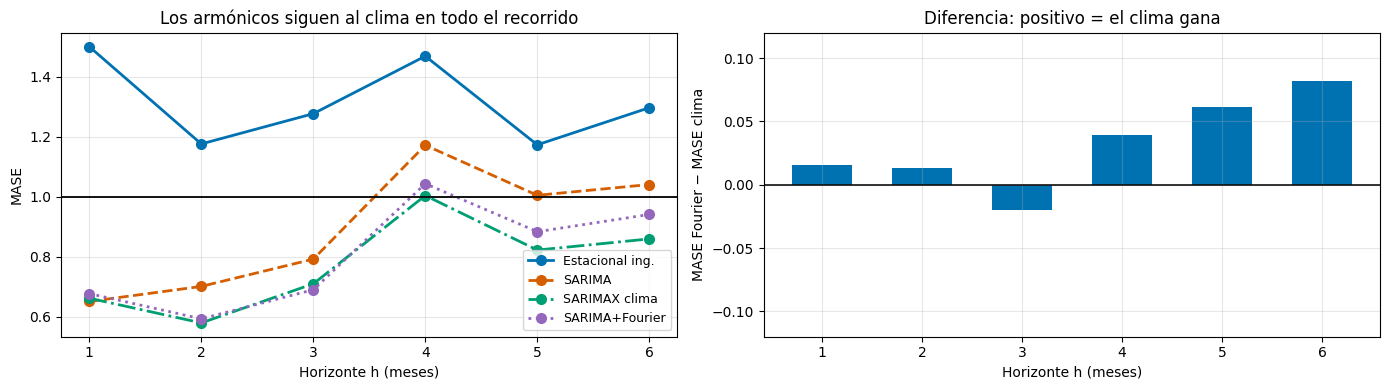

Diebold-Mariano, referencia SARIMAX clima:


,,DM,p,n,veredicto
h = 1,SARIMA+Fourier,-0.46,0.6524,27,sin diferencia detectable
h = 2,SARIMA+Fourier,-0.87,0.3913,27,sin diferencia detectable
h = 3,SARIMA+Fourier,-1.33,0.1942,27,sin diferencia detectable
h = 6,SARIMA+Fourier,0.83,0.4124,27,sin diferencia detectable


In [42]:
mase_h4 = mase_por_horizonte(bt, COLS4)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ESTILOS = ["-", "--", "-.", ":"]
for (m, serie), color, estilo in zip(mase_h4.items(), PAL, ESTILOS):
    ax[0].plot(serie.index, serie.values, color=color, ls=estilo, lw=2, marker="o", ms=7, label=m)
ax[0].axhline(1.0, color=OBS, lw=1.4)
ax[0].set_xlabel("Horizonte h (meses)"); ax[0].set_ylabel("MASE")
ax[0].set_title("Los armónicos siguen al clima en todo el recorrido")
ax[0].legend(fontsize=9, loc="lower right")

dif = (mase_h4["SARIMA+Fourier"] - mase_h4["SARIMAX clima"])
ax[1].bar(dif.index, dif.values, color=PAL[0], width=0.6)
ax[1].axhline(0, color=OBS, lw=1.2)
ax[1].set_xlabel("Horizonte h (meses)"); ax[1].set_ylabel("MASE Fourier − MASE clima")
ax[1].set_title("Diferencia: positivo = el clima gana")
ax[1].set_ylim(-0.12, 0.12)
plt.tight_layout(); plt.show()

print("Diebold-Mariano, referencia SARIMAX clima:")
tabla_dm(bt, "SARIMAX clima", ["SARIMA+Fourier"])

**Lectura. Este es el resultado más importante del notebook.**

Dos armónicos de Fourier, **sin un solo dato climático**, igualan al SARIMAX con clima:

| | MASE global | h = 1 | h = 3 | h = 6 |
|---|---|---|---|---|
| SARIMA | 0,89 | 0,65 | 0,79 | 1,04 |
| SARIMAX clima | 0,77 | 0,66 | 0,71 | 0,86 |
| **SARIMA + Fourier** | **0,80** | 0,68 | 0,69 | 0,94 |

Y Diebold-Mariano **no detecta diferencia en ningún horizonte** (p = 0,65, 0,39, 0,19 y 0,41). El RMSE global incluso favorece a los armónicos (16,50 contra 16,88).

**Qué significa, dicho sin adornos.** La mejora que el clima le da al pronóstico de dengue en Montería es, en su casi totalidad, **la estacionalidad anual**. Y la estacionalidad anual se puede escribir con cuatro senos y cosenos que no requieren medir nada. El clima no está aportando alerta temprana: está aportando un calendario.

**El detalle que cierra el argumento.** Al incluir la humedad, el AICc deja de pedir el término estacional (la mejor especificación con clima es `(0,0,0)[12]`, sin componente estacional). La humedad **está ocupando el lugar** de la parte estacional del modelo. No es una metáfora: es lo que hace el criterio de información cuando se le deja elegir.

**Lo que no dice este resultado**, porque la tentación de sobreinterpretar es simétrica:

- No dice que el clima sea irrelevante para la transmisión del dengue. Lo es, y hay mecanismos biológicos bien establecidos. Dice que, **a escala municipal, mensual y con un modelo lineal**, la información climática que importa para pronosticar es la que ya está en el calendario.
- No dice que el artículo de referencia esté equivocado. Dice que su comparación —SARIMAX contra SARIMA— no incluía el competidor relevante. Es una omisión frecuentísima: comparar contra un modelo peor y no contra el modelo barato que hace lo mismo.
- Sí sugiere qué habría que medir para encontrar señal climática de verdad: **anomalías** respecto a la normal (no niveles), eventos extremos, índices de ENSO con rezagos largos, o resolución espacial más fina. El dato agregado al municipio y al mes puede ser simplemente demasiado grueso.

**La lección transferible.** Cuando una variable exógena mejora el pronóstico, hay que preguntarse *qué parte* de ella lo está mejorando. Si es la parte periódica, un término determinista la reemplaza gratis. La comparación contra armónicos de Fourier debería ser un paso obligado en cualquier SARIMAX con regresores estacionales, y casi nunca se hace.

## 17. ¿Hubo una ruptura en 2020?

La pandemia desorganizó la vigilancia epidemiológica: consultas pospuestas, personal reasignado, notificación interrumpida. En muchas series de enfermedades transmisibles 2020 aparece como un escalón hacia abajo que no corresponde a la transmisión real, sino al sistema que la mide.

Nuestro entrenamiento **incluye 2020 y 2021**. Si hubo un escalón y no lo modelamos, los parámetros quedan contaminados.

La forma estándar de probarlo es un **análisis de intervención** (Box y Tiao, 1975): se agrega una variable indicadora que vale 1 durante la ventana afectada y 0 el resto, y se mira su coeficiente. Como no sabemos de antemano cuándo terminó la alteración, probamos tres ventanas plausibles. Importante: probar tres ventanas y quedarse con la mejor es una forma leve de *data snooping*, así que lo que vale es el patrón de las tres, no la que mejor salga.

In [43]:
def indicadora(desde, hasta, nombre="covid"):
    d = pd.Series(0.0, index=df.index, name=nombre)
    d.loc[desde:hasta] = 1.0
    return d

filas = {}
for etiqueta, (desde, hasta) in {
        "mar 2020 – dic 2020": ("2020-03", "2020-12"),
        "mar 2020 – jun 2021": ("2020-03", "2021-06"),
        "mar 2020 – dic 2021": ("2020-03", "2021-12")}.items():
    Xd = X.join(indicadora(desde, hasta))
    r = SARIMAX(y_tr, exog=Xd[INI:FIN_TRAIN], order=ORDEN,
                seasonal_order=ORDEN_EST).fit(disp=False, maxiter=800)
    filas[etiqueta] = {"AIC": r.aic, "BIC": r.bic,
                       "β covid": r.params["covid"], "p": r.pvalues["covid"],
                       "efecto (%)": 100 * (np.exp(r.params["covid"]) - 1)}
filas["sin indicadora"] = {"AIC": sarimax.aic, "BIC": sarimax.bic,
                           "β covid": np.nan, "p": np.nan, "efecto (%)": np.nan}
pd.DataFrame(filas).T.round(3)

,AIC,BIC,β covid,p,efecto (%)
mar 2020 – dic 2020,323.327,345.440,-0.429,0.345,-34.873
mar 2020 – jun 2021,320.591,342.704,-0.810,0.192,-55.532
mar 2020 – dic 2021,323.383,345.497,-0.538,0.508,-41.602
sin indicadora,322.323,341.278,NaN,NaN,NaN


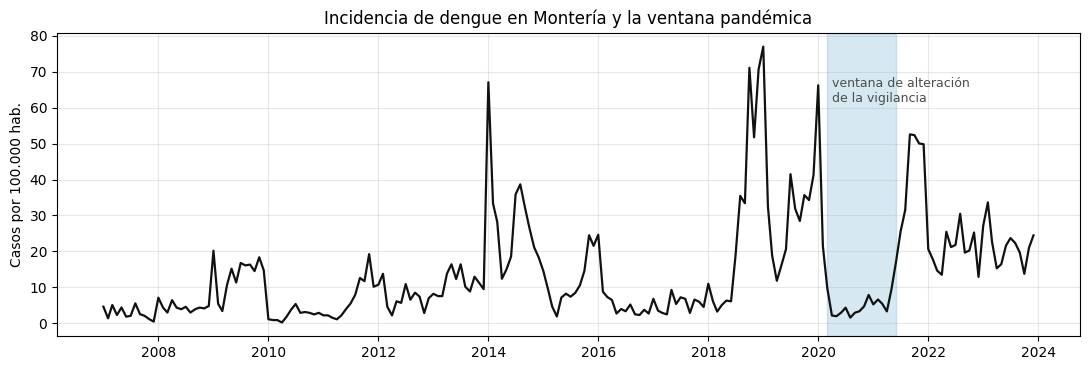

In [44]:
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(df["Y"], color=OBS, lw=1.6)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-01"), color=PAL[0], alpha=0.16)
ax.annotate("ventana de alteración\nde la vigilancia", xy=(pd.Timestamp("2020-04-01"), df["Y"].max() * 0.80),
            fontsize=9, color="0.30")
ax.set_title("Incidencia de dengue en Montería y la ventana pandémica")
ax.set_ylabel("Casos por 100.000 hab.")
plt.tight_layout(); plt.show()

**Lectura, y el resultado es un no.**

Ninguna de las tres ventanas da un coeficiente significativo (p = 0,35, 0,19 y 0,51) y el AIC apenas se mueve respecto al modelo sin indicadora (322,3 contra 320,6–323,4). Los puntos estimados sugieren una caída de 35 % a 56 %, pero los intervalos son tan anchos que incluyen el cero con holgura.

**Por qué no se detecta, aunque el efecto exista.** El AR(1) tiene φ = 0,88, casi una raíz unitaria. Un modelo así absorbe un escalón de nivel sin protestar: lo explica como una sucesión de choques persistentes. Es el mismo fenómeno por el que un ARIMA con d = 1 nunca "ve" un cambio de nivel. La indicadora y el AR compiten por explicar la misma cosa, y con 174 observaciones el AR gana.

**Lo que NO se puede concluir.** "La pandemia no afectó la notificación de dengue en Montería" sería una lectura equivocada de esta tabla. Lo correcto es: *con esta especificación y esta longitud de muestra, el efecto no es separable de la dinámica autorregresiva*. Es una limitación de potencia, no evidencia de ausencia. 2020 también fue un año de baja transmisión real en buena parte del Caribe colombiano, así que los dos efectos —menos transmisión y menos notificación— están confundidos y ningún modelo de esta serie los va a separar.

**La lección metodológica.** Una intervención que uno sabe que ocurrió puede ser indetectable, y eso no la vuelve inexistente. Cuando una indicadora teóricamente justificada sale no significativa, hay que preguntarse si el modelo tenía la capacidad de detectarla antes de declarar que no pasó nada.

## 18. El orden del artículo, la advertencia sobre `d`, y cómo elegir sin mirar la prueba

Probamos otras dos especificaciones del artículo adaptadas a m = 12:

- **(4,1,3)(1,0,1)**: el mejor modelo de los autores.
- **(1,1,1)(0,0,1)**: el más sencillo de los que reportan.

Las dos tienen d = 1, aunque ADF y KPSS con tendencia dijeron que no hacía falta.

**Advertencia antes de leer la tabla.** La columna de RMSE sobre la prueba se calcula aquí para *ilustrar* un punto, no para elegir el modelo. En el momento en que uno mira el RMSE de prueba de seis especificaciones y se queda con la mejor, el periodo de prueba deja de ser prueba: se convierte en un segundo conjunto de validación, y el RMSE reportado queda sesgado hacia abajo. Es el error de selección más común en los trabajos aplicados, y es invisible en el resultado final. La forma correcta de elegir está en 18.1.

In [45]:
def evaluar(orden, orden_est, exog):
    xtr, xte = (X_tr, X_te) if exog else (None, None)
    res = SARIMAX(y_tr, exog=xtr, order=orden, seasonal_order=orden_est).fit(disp=False, maxiter=500)
    f1, f24 = pronosticar(res, xte)
    return {"AIC": res.aic, "RMSE 1 mes": metricas(real, f1)["RMSE"], "RMSE 24 meses": metricas(real, f24)["RMSE"]}

filas = {}
for orden, orden_est in [((1, 0, 1), (0, 0, 1, 12)), ((4, 1, 3), (1, 0, 1, 12)), ((1, 1, 1), (0, 0, 1, 12))]:
    for exog in (False, True):
        filas[(f"{orden}{orden_est[:3]}[12]", "SARIMAX" if exog else "SARIMA")] = evaluar(orden, orden_est, exog)
comparacion = pd.DataFrame(filas).T.round(2)
comparacion

AIC  RMSE 1 mes  RMSE 24 meses
(1, 0, 1)(0, 0, 1)[12] SARIMA   342.57        7.89          11.54
                       SARIMAX  322.32        7.12           9.18
(4, 1, 3)(1, 0, 1)[12] SARIMA   321.30        8.54          12.83
                       SARIMAX  319.78        6.47           8.63
(1, 1, 1)(0, 0, 1)[12] SARIMA   332.12        7.05           8.23
                       SARIMAX  323.74        8.55          26.52

**Lectura.**
- Con el orden del mejor modelo del artículo, SARIMAX vuelve a ganar con claridad.
- Con (1,1,1)(0,0,1), SARIMAX tiene **mejor AIC y peor pronóstico**, y a 24 meses se desborda (RMSE 26,5).

**Dos lecciones.** El AIC mide ajuste dentro de la muestra, no capacidad de pronóstico: siempre hay que validar fuera de muestra. Y diferenciar una serie que ya es estacionaria puede dañar el pronóstico de largo plazo, porque un modelo con d = 1 extrapola el último nivel en vez de volver a la media, y con 24 pasos esa deriva se acumula.

Nota: el modelo (4,1,3)(1,0,1) tiene 12 parámetros para 174 datos y su estimación es numéricamente delicada; las cifras pueden variar en el segundo decimal entre versiones de statsmodels.

### 18.1 Elegir el orden con AICc, usando solo el entrenamiento

Si no se puede mirar la prueba, ¿cómo se elige? Con un criterio de información calculado **solo sobre el entrenamiento**, y luego una única evaluación fuera de muestra que no retroalimenta la elección.

Usamos **AICc** en lugar de AIC. La corrección de segundo orden

$$\text{AICc} = \text{AIC} + \frac{2k(k+1)}{n-k-1}$$

importa cuando n/k es pequeño. Con n = 174 y hasta 8 parámetros la diferencia es de un par de puntos, suficiente para cambiar el ganador entre modelos cercanos. Para los modelos de 12 parámetros del artículo la corrección ya pesa de verdad.

**La celda tarda alrededor de un minuto y medio** (144 ajustes).

In [46]:
REJILLA = [(p, d, q, P, Q)
           for d in (0, 1) for p in (0, 1, 2) for q in (0, 1, 2) for P in (0, 1) for Q in (0, 1)]
GRUPOS = {"sin clima": None, "con humedad": ["hr_lag2"]}

filas = []
for grupo, cols in GRUPOS.items():
    xtr = X_tr[cols] if cols else None
    for p, d, q, P, Q in REJILLA:
        try:
            r = SARIMAX(y_tr, exog=xtr, order=(p, d, q),
                        seasonal_order=(P, 0, Q, 12)).fit(disp=False, maxiter=400)
            filas.append({"exógenas": grupo, "orden": f"({p},{d},{q})({P},0,{Q})[12]",
                          "d": d, "estacional": P + Q, "AICc": aicc(r), "k": len(r.params)})
        except Exception:
            pass
rejilla = pd.DataFrame(filas)
print(f"{len(rejilla)} modelos ajustados sobre el entrenamiento.\n")
for grupo in GRUPOS:
    print(f"--- mejores 3 {grupo} ---")
    print(rejilla[rejilla["exógenas"] == grupo].nsmallest(3, "AICc").to_string(index=False), "\n")

144 modelos ajustados sobre el entrenamiento.

--- mejores 3 sin clima ---
 exógenas              orden  d  estacional       AICc  k
sin clima (2,1,1)(1,0,1)[12]  1           2 324.459688  6
sin clima (1,1,1)(1,0,1)[12]  1           2 326.071694  5
sin clima (2,1,2)(1,0,1)[12]  1           2 326.092543  7 

--- mejores 3 con humedad ---
   exógenas              orden  d  estacional       AICc  k
con humedad (2,1,1)(0,0,0)[12]  1           0 317.961125  5
con humedad (0,1,1)(0,0,0)[12]  1           0 318.668032  3
con humedad (2,1,2)(0,0,0)[12]  1           0 318.804459  6 



In [47]:
# ¿Qué pide el AICc cuando el clima está presente?
print("Promedio de AICc según si el modelo lleva componente estacional:")
print(rejilla.assign(estacional=rejilla["estacional"] > 0)
             .groupby(["exógenas", "estacional"])["AICc"].min().round(2).to_string())

mejor = rejilla.nsmallest(1, "AICc").iloc[0]
print(f"\nMejor global por AICc: {mejor['orden']}  {mejor['exógenas']}  AICc = {mejor['AICc']:.2f}")

# Una sola evaluación fuera de muestra, con el MISMO origen rodante de la sección 14.
bt_aicc = backtest({"SARIMAX AICc (2,1,1)": dict(exog=X[["hr_lag2"]], orden=(2, 1, 1), est=(0, 0, 0, 12))})
bt = bt.join(bt_aicc[["SARIMAX AICc (2,1,1)"]])
print()
resumen_backtest(bt, ["SARIMA", "SARIMAX clima", "SARIMA+Fourier", "SARIMAX AICc (2,1,1)"]).round(2)

Promedio de AICc según si el modelo lleva componente estacional:
exógenas     estacional
con humedad  False         317.96
             True          319.34
sin clima    False         335.05
             True          324.46

Mejor global por AICc: (2,1,1)(0,0,0)[12]  con humedad  AICc = 317.96


,RMSE,MAE,MASE
SARIMA,17.65,11.85,0.89
SARIMAX clima,16.88,10.25,0.77
SARIMA+Fourier,16.50,10.67,0.80
"SARIMAX AICc (2,1,1)",16.51,11.22,0.85


**Lectura, y confirma dos cosas distintas.**

**Primero, el AICc contradice al notebook en dos puntos.** La mejor especificación por AICc es `(2,1,1)(0,0,0)[12]` con humedad: pide **d = 1**, al contrario de lo que sugerían ADF y KPSS, y **descarta el componente estacional** por completo. Comparando los mínimos por grupo se ve el patrón: sin clima, el AICc exige términos estacionales; con humedad, no los quiere. Es la evidencia más limpia de que **la humedad está ocupando el lugar de la estacionalidad** (sección 16), y sale de un criterio automático que no sabe nada de nuestra hipótesis.

**Segundo, el AICc tampoco acierta fuera de muestra.** El modelo que el AICc elige no es el que mejor pronostica sobre los 27 orígenes: el SARIMAX de la sección 14 y el de armónicos siguen adelante. Esto no es raro ni es un fallo del criterio: AICc aproxima la divergencia de Kullback-Leibler **dentro de la muestra**, lo cual no es lo mismo que minimizar el error de pronóstico a varios pasos. Es la misma lección de la tabla anterior, ahora con un criterio bien calculado y una validación decente.

**Cómo se hace entonces.** Elegir por AICc sobre el entrenamiento es defendible y reproducible. Elegir por error de pronóstico en validación de origen rodante —también solo con datos anteriores a la prueba— es mejor si lo que interesa es pronosticar. Lo que no es defendible es elegir mirando la prueba y reportar ese mismo número como desempeño fuera de muestra.

## 19. Lo que este modelo no es

Un SARIMAX gaussiano sobre log(tasa) es una herramienta razonable y es la que usa la literatura aplicada. Pero conviene saber qué supuestos se están aceptando, porque hay tres que no son inocentes aquí.

**1. Los datos son conteos, no una variable continua.** `Y` es una tasa, pero por debajo hay `Casos` (entre 1 y 384) sobre `Poblacion`. El modelo natural para eso es un GLM de conteo con la población como *offset*:

$$\text{Casos}_t \sim \text{BinNeg}(\mu_t, \theta), \qquad \log \mu_t = \log(\text{Poblacion}_t) + \beta' X_t + \text{estacionalidad} + \ldots$$

Ventajas concretas: no hay que inventar qué hacer con los ceros (aquí no hay, pero en municipios más pequeños sí), la varianza crece con la media como de hecho ocurre, y el *offset* trata correctamente el crecimiento poblacional —que en Montería fue del 21 % en el periodo— en vez de absorberlo en la tasa.

**2. La relación es lineal en los parámetros.** La respuesta del dengue a la temperatura es claramente no monótona: hay un óptimo para el mosquito y por encima la transmisión cae. Un coeficiente lineal sobre `X3` no puede representar eso, lo que explica en parte por qué la temperatura no aparece como significativa. Un DLNM (*distributed lag non-linear model*, Gasparrini) es el estándar en epidemiología ambiental precisamente para capturar a la vez la no linealidad y la estructura de rezagos.

**3. La dinámica es del error, no del proceso.** En un SARIMAX la autocorrelación está en el término de error. En una epidemia la dependencia es del proceso: los casos de este mes causan los del mes entrante por transmisión. Los modelos tipo INGARCH / `hhh4` (del paquete **surveillance**) ponen la autorregresión en la media condicional del conteo, que es donde corresponde, y separan un componente endémico de uno epidémico.

**Y el límite que ningún cambio de modelo resuelve.** La magnitud de un brote de dengue depende de qué serotipo circula y de la inmunidad acumulada de la población frente a ese serotipo. Ninguna de esas dos variables está en estos datos, ni en el clima. Es la razón de fondo por la que la sección 12 produce intervalos tan anchos: falta la variable que explica los brotes, y no es climática.

Esto no invalida el ejercicio. Lo ubica: es un modelo de la **estacionalidad y la inercia** de la incidencia, útil a horizontes de pocos meses, que no pretende anticipar epidemias.

In [48]:
# ¿Los conteos están sobredispersos? Si la varianza supera a la media, Poisson no sirve
# y hay que ir a binomial negativa. Es una línea y evita un modelo mal especificado.
c = df["Casos"]
print(f"media = {c.mean():.1f}   varianza = {c.var():.1f}   razón = {c.var() / c.mean():.1f}")
print("Con Poisson la razón debería ser ≈ 1. Aquí la varianza es 77 veces la media:")
print("sobredispersión fuerte, así que el modelo de conteo tendría que ser binomial negativo,")
print("no Poisson. Con Poisson los errores estándar saldrían absurdamente pequeños.")

media = 68.2   varianza = 5253.8   razón = 77.0
Con Poisson la razón debería ser ≈ 1. Aquí la varianza es 77 veces la media:
sobredispersión fuerte, así que el modelo de conteo tendría que ser binomial negativo,
no Poisson. Con Poisson los errores estándar saldrían absurdamente pequeños.


## 20. Conclusiones

### Sobre la pregunta de la clase

1. **Agregar clima mejora el pronóstico, pero solo a horizontes medios.** Sobre 27 orígenes, el SARIMAX con humedad y precipitación rezagadas dos meses le gana al SARIMA a 4–6 meses (Diebold-Mariano p = 0,006 a h = 6). **A 1–3 meses no se detecta diferencia.** La ventaja de la partición única (sección 9) no sobrevivió a la validación rodante.

2. **Esa mejora es estacionalidad, no información climática.** Dos armónicos de Fourier, sin ningún dato climático, igualan al SARIMAX en todos los horizontes (DM sin diferencia significativa, p entre 0,19 y 0,65). La CCF preblanqueada ya no mostraba ninguna relación de adelanto, y sustituir el clima observado por normales climatológicas no empeoró nada. Las tres pistas apuntan al mismo sitio.

3. **De las dos exógenas, solo la humedad relativa aporta**, y no por colinealidad (VIF = 2,07) sino porque la precipitación simplemente no agrega nada una vez está la humedad. Por BIC, el mejor modelo lleva humedad sola.

4. **Los dos modelos le ganan al piso trivial, pero por menos de lo que parece.** A 1 mes, el pronóstico ingenuo tiene MASE 0,50 contra 0,40 del SARIMAX. A 24 meses, la climatología —cero parámetros— le gana al SARIMA.

5. **Los intervalos son honestos e inútiles.** La banda al 80 % del SARIMAX a 24 meses mide 54 casos por 100.000, sobre un periodo de prueba que promedia 21, y cubre el 100 % de los meses en lugar del 80 %. El modelo no puede anticipar brotes porque las variables que los determinan —serotipos, inmunidad— no están en estos datos.

### Sobre el oficio

Las conclusiones 1 y 2 **contradicen** la lectura de la sección 9, que es la que produciría un análisis estándar. Vale la pena mirar qué hizo falta para encontrar la diferencia:

| Práctica | Qué habría pasado sin ella |
|---|---|
| CCF **preblanqueada** | correlaciones de 0,20 leídas como señal climática |
| Benchmarks triviales y **MASE** | "RMSE 7,1" sin forma de juzgar si es bueno |
| Distinguir mediana de media al volver de log | RMSE de 11,5 o de 52,9 según la línea que se escriba |
| Evaluar **cobertura** de intervalos, no solo el punto | bandas inservibles presentadas como resultado |
| Pronóstico **ex ante** | ventaja del clima inflada por previsión perfecta |
| **Origen rodante** con reestimación | ventaja a 1 mes que era ruido de una partición |
| **Diebold-Mariano** | "gana en todas las métricas" sin medir si es distinguible del azar |
| Comparar contra **armónicos de Fourier** | atribuir al clima lo que hace el calendario |
| Elegir el orden **sin mirar la prueba** | desempeño reportado sesgado hacia abajo |

Ninguna de estas nueve es exótica, y ninguna requiere más de veinte líneas de código. La mayoría falta en la literatura aplicada de pronóstico de dengue, y la que falta con más frecuencia es la última de la lista de fondo: **un competidor barato que haga lo mismo**.

Si hay una sola idea que llevarse: *mejor que el modelo anterior* no es lo mismo que *útil*, y *significativo dentro de la muestra* no es lo mismo que *mejor pronóstico*. Las dos confusiones se resuelven con benchmarks y validación fuera de muestra, en ese orden.

## 21. Ejercicios

**Básicos** (modifican una celda y se corren en segundos)

1. Cambien el rezago a 1 y a 3 meses en `LAG`. ¿Cambia alguna conclusión de la sección 14?
2. Agreguen la temperatura (`X3`) como tercera exógena. ¿Es significativa? ¿Qué dice el VIF? ¿Mejora el AICc?
3. Quiten la precipitación y dejen solo la humedad. Comparen AIC, BIC y el MASE del origen rodante. ¿Coinciden los tres criterios?
4. Modelen `Casos` en lugar de la tasa. ¿Qué cambia, y qué pasa con el crecimiento poblacional del 21 %?
5. Muevan la partición: entrenen hasta 2019 y prueben con 2020–2021. ¿Qué pasa con un periodo de prueba que incluye la pandemia y un brote?

**Sobre el control de calidad**

6. En la sección 11, implementen la media del pronóstico por **simulación**: `sarimax.simulate` con 2.000 trayectorias, exponenciar y promediar. ¿Se acerca más al observado que `exp(μ̂ + σ̂²/2)`? ¿Qué dice eso sobre el supuesto de normalidad?
7. Suban `K` a 3 en los armónicos de Fourier. ¿Mejora o empieza a sobreajustar? Úsenlo como excusa para elegir K por AICc.
8. Cambien `PASO` de 3 a 1 en el origen rodante: 78 orígenes en vez de 27. ¿Gana potencia la prueba de Diebold-Mariano? ¿Cambia algún veredicto a 1–3 meses?
9. Implementen la prueba de **Clark-West** para el caso anidado (SARIMA está dentro de SARIMAX) y compárenla con Diebold-Mariano. ¿Cambia la conclusión a h = 1?
10. Calculen el **interval score** al 80 % para los cuatro modelos del origen rodante. ¿El ranking por puntaje de intervalo coincide con el ranking por MASE?

**Para pensar**

11. La sección 16 muestra que el clima actúa como proxy de estacionalidad. Diseñen una variable climática que **no** pueda ser imitada por armónicos: por ejemplo la anomalía mensual de humedad respecto a su propia normal. Agréguenla y prueben. ¿Aparece señal?
12. El coeficiente de la humedad se duplica al agregar tendencia (sección 3). ¿Cuál de los dos valores reportarían en un artículo, y cómo lo justificarían?
13. La sección 17 no detecta la ruptura de 2020. Diseñen una forma de darle al modelo más posibilidad de detectarla (por ejemplo estimando sin el AR, o con una indicadora de pulso en lugar de escalón). ¿Aparece?
14. Repliquen las secciones 10 a 16 para otro municipio del conjunto de datos de Zenodo. ¿La conclusión sobre el clima como proxy de estacionalidad se sostiene, o Montería es un caso particular?

## Referencias

### Caso y datos

- Medina E, Cogollo MR, González-Parra G (2024). Prescriptive temporal modeling approach using climate variables to forecast dengue incidence in Córdoba, Colombia. *Mathematical Biosciences and Engineering*, 21(12), 7760–7782. https://doi.org/10.3934/mbe.2024341
- Marcelo C, Meneses Bernal JE, Quesada B, Ramírez JD, Avila Diaz AJ, Universidad del Rosario (2026). Monthly dengue surveillance and climate dataset for 60 hyperendemic municipalities in Colombia (2007–2023). Zenodo. https://doi.org/10.5281/zenodo.21538313

### Métodos usados en las secciones 10 a 18

- Box GEP, Jenkins GM, Reinsel GC, Ljung GM (2015). *Time Series Analysis: Forecasting and Control*, 5.ª ed. Wiley. — Preblanqueo y funciones de transferencia, capítulos 11 y 12 (sección 4.1).
- Box GEP, Tiao GC (1975). Intervention analysis with applications to economic and environmental problems. *JASA*, 70(349), 70–79. — Análisis de intervención (sección 17).
- Cleveland RB, Cleveland WS, McRae JE, Terpenning I (1990). STL: A seasonal-trend decomposition procedure based on loess. *Journal of Official Statistics*, 6(1), 3–73. — Sección 3.
- Hyndman RJ, Koehler AB (2006). Another look at measures of forecast accuracy. *International Journal of Forecasting*, 22(4), 679–688. — MASE y por qué el MAPE falla (sección 10).
- Diebold FX, Mariano RS (1995). Comparing predictive accuracy. *Journal of Business & Economic Statistics*, 13(3), 253–263. — Sección 15.
- Harvey D, Leybourne S, Newbold P (1997). Testing the equality of prediction mean squared errors. *International Journal of Forecasting*, 13(2), 281–291. — Corrección de muestra pequeña (sección 15).
- Clark TE, West KD (2007). Approximately normal tests for equal predictive accuracy in nested models. *Journal of Econometrics*, 138(1), 291–311. — El caso anidado (sección 15).
- Gneiting T, Raftery AE (2007). Strictly proper scoring rules, prediction, and estimation. *JASA*, 102(477), 359–378. — Evaluar distribuciones, no puntos (sección 12).
- Hurvich CM, Tsai CL (1989). Regression and time series model selection in small samples. *Biometrika*, 76(2), 297–307. — AICc (sección 18).
- Hyndman RJ, Athanasopoulos G (2021). *Forecasting: Principles and Practice*, 3.ª ed. OTexts. https://otexts.com/fpp3/ — Fuerza de estacionalidad, armónicos de Fourier, validación de origen rodante. Lectura de referencia para casi todo el bloque 10–18.

### Para ir más allá del SARIMAX (sección 19)

- Gasparrini A, Armstrong B, Kenward MG (2010). Distributed lag non-linear models. *Statistics in Medicine*, 29(21), 2224–2234.
- Held L, Höhle M, Hofmann M (2005). A statistical framework for the analysis of multivariate infectious disease surveillance counts. *Statistical Modelling*, 5(3), 187–199. — Los modelos `hhh4` del paquete **surveillance**.
- Bhaskaran K, Gasparrini A, Hajat S, Smeeth L, Armstrong B (2013). Time series regression studies in environmental epidemiology. *International Journal of Epidemiology*, 42(4), 1187–1195.
- Lowe R, Bailey TC, Stephenson DB y otros (2011). Spatio-temporal modelling of climate-sensitive disease risk: towards an early warning system for dengue in Brazil. *Computers & Geosciences*, 37(3), 371–381.